#  Liver Patient Classification Project



##  Import Libraries



In [2]:
# pip install shap

In [79]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.impute import KNNImputer
from sklearn.preprocessing import RobustScaler, LabelEncoder
from sklearn.model_selection import (train_test_split, StratifiedKFold,GridSearchCV, learning_curve)
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,f1_score, roc_auc_score, confusion_matrix,classification_report, roc_curve)
import shap
import joblib

---

##  Load Data


In [ ]:
# Load dataset (latin-1 encoding handles special characters in column names)
df = pd.read_csv('Liver Patient Dataset.csv', encoding='latin-1')
print("=" * 55)
print(f"  Dataset Shape : {df.shape[0]:,} rows × {df.shape[1]} columns")
print("=" * 55)
df.head(10)

  Dataset Shape : 30,691 rows × 11 columns


,Age of the patient,Gender of the patient,Total Bilirubin,Direct Bilirubin,Alkphos Alkaline Phosphotase,Sgpt Alamine Aminotransferase,Sgot Aspartate Aminotransferase,Total Protiens,ALB Albumin,A/G Ratio Albumin and Globulin Ratio,Result
0,65.0,Female,0.7,0.1,187.0,16.0,18.0,6.8,3.3,0.90,1
1,62.0,Male,10.9,5.5,699.0,64.0,100.0,7.5,3.2,0.74,1
2,62.0,Male,7.3,4.1,490.0,60.0,68.0,7.0,3.3,0.89,1
3,58.0,Male,1.0,0.4,182.0,14.0,20.0,6.8,3.4,1.00,1
4,72.0,Male,3.9,2.0,195.0,27.0,59.0,7.3,2.4,0.40,1
5,46.0,Male,1.8,0.7,208.0,19.0,14.0,7.6,4.4,1.30,1
6,26.0,Female,0.9,0.2,154.0,NaN,12.0,7.0,3.5,1.00,1
7,29.0,Female,0.9,0.3,202.0,14.0,11.0,6.7,3.6,1.10,1
8,17.0,Male,0.9,0.3,202.0,22.0,19.0,7.4,4.1,1.20,2
9,55.0,Male,0.7,0.2,290.0,53.0,58.0,6.8,3.4,1.00,1


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30691 entries, 0 to 30690
Data columns (total 11 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Age of the patient                    30689 non-null  float64
 1   Gender of the patient                 29789 non-null  object 
 2   Total Bilirubin                       30043 non-null  float64
 3   Direct Bilirubin                      30130 non-null  float64
 4    Alkphos Alkaline Phosphotase         29895 non-null  float64
 5    Sgpt Alamine Aminotransferase        30153 non-null  float64
 6   Sgot Aspartate Aminotransferase       30229 non-null  float64
 7   Total Protiens                        30228 non-null  float64
 8    ALB Albumin                          30197 non-null  float64
 9   A/G Ratio Albumin and Globulin Ratio  30132 non-null  float64
 10  Result                                30691 non-null  int64  
dtypes: float64(9), 

In [ ]:
# Statistical summary
print("Statistical Summary")
df.describe(include='all').T

Statistical Summary


,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Age of the patient,30689.0,NaN,NaN,NaN,44.107205,15.981043,4.0,32.0,45.0,55.0,90.0
Gender of the patient,29789,2,Male,21986,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Total Bilirubin,30043.0,NaN,NaN,NaN,3.370319,6.255522,0.4,0.8,1.0,2.7,75.0
Direct Bilirubin,30130.0,NaN,NaN,NaN,1.528042,2.869592,0.1,0.2,0.3,1.3,19.7
Alkphos Alkaline Phosphotase,29895.0,NaN,NaN,NaN,289.075364,238.537589,63.0,175.0,209.0,298.0,2110.0
Sgpt Alamine Aminotransferase,30153.0,NaN,NaN,NaN,81.488641,182.15885,10.0,23.0,35.0,62.0,2000.0
Sgot Aspartate Aminotransferase,30229.0,NaN,NaN,NaN,111.469979,280.851078,10.0,26.0,42.0,88.0,4929.0
Total Protiens,30228.0,NaN,NaN,NaN,6.480237,1.08198,2.7,5.8,6.6,7.2,9.6
ALB Albumin,30197.0,NaN,NaN,NaN,3.130142,0.792281,0.9,2.6,3.1,3.8,5.5
A/G Ratio Albumin and Globulin Ratio,30132.0,NaN,NaN,NaN,0.943467,0.323164,0.3,0.7,0.9,1.1,2.8


---

##  Data Validation

Before building any model, we **validate the data quality** thoroughly:
1. Check for duplicates
2. Check missing values
3. Validate data types
4. Inspect feature ranges per class (medical check)


In [ ]:
# ── Step 4.1 : Clean column names (strip leading/trailing whitespace & non-breaking spaces) ──
df.columns = df.columns.str.strip().str.replace('\xa0', '', regex=False)
print("Cleaned column names:")
for c in df.columns:
    print(f"   • {c}")

Cleaned column names:
   • Age of the patient
   • Gender of the patient
   • Total Bilirubin
   • Direct Bilirubin
   • Alkphos Alkaline Phosphotase
   • Sgpt Alamine Aminotransferase
   • Sgot Aspartate Aminotransferase
   • Total Protiens
   • ALB Albumin
   • A/G Ratio Albumin and Globulin Ratio
   • Result


In [8]:
#  Duplicate check 
n_dupes = df.duplicated().sum()
print(f"Duplicate rows : {n_dupes:,}")
if n_dupes > 0:
    df = df.drop_duplicates()
    print(f"   → Removed. New shape: {df.shape}")
else:
    print("   → No duplicates found.")


Duplicate rows : 11,323
   → Removed. New shape: (19368, 11)


In [9]:
#  Missing values 
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0')
display(missing_df.style.background_gradient(cmap='Reds'))

,Missing Count,Missing %
Age of the patient,1,0.010000
Gender of the patient,796,4.110000
Total Bilirubin,557,2.880000
Direct Bilirubin,490,2.530000
Alkphos Alkaline Phosphotase,694,3.580000
Sgpt Alamine Aminotransferase,459,2.370000
Sgot Aspartate Aminotransferase,393,2.030000
Total Protiens,370,1.910000
ALB Albumin,413,2.130000
A/G Ratio Albumin and Globulin Ratio,436,2.250000


In [ ]:
#  Data types validation
print(" Data Types:")
print(df.dtypes)
print()
# Encode Gender (Male=1, Female=0)
le = LabelEncoder()
df['Gender of the patient'] = le.fit_transform(df['Gender of the patient'])
print(" Gender encoded → Male=1, Female=0")
print(df['Gender of the patient'].value_counts())


 Data Types:
Age of the patient                      float64
Gender of the patient                    object
Total Bilirubin                         float64
Direct Bilirubin                        float64
Alkphos Alkaline Phosphotase            float64
Sgpt Alamine Aminotransferase           float64
Sgot Aspartate Aminotransferase         float64
Total Protiens                          float64
ALB Albumin                             float64
A/G Ratio Albumin and Globulin Ratio    float64
Result                                    int64
dtype: object

 Gender encoded → Male=1, Female=0
Gender of the patient
1    13019
0     5553
2      796
Name: count, dtype: int64


In [ ]:
# Remap target to binary 0/1 ───────────────────
# Original: 1=Liver Patient, 2=Non-Liver Patient
# New:      1=Liver Patient, 0=Non-Liver Patient
df['Result'] = df['Result'].map({1: 1, 2: 0})
print("Target remapped → 1=Liver Patient, 0=Healthy")
print(df['Result'].value_counts())

✅ Target remapped → 1=Liver Patient, 0=Healthy
Result
1    13811
0     5557
Name: count, dtype: int64


### Per-class feature statistics (medical validation)


In [ ]:
TARGET = 'Result'
feature_cols = [c for c in df.columns if c != TARGET]

print("=" * 70)
print("  Per-Class Feature Statistics")
print("  (1 = Liver Patient  |  0 = Healthy)")
print("=" * 70)

class_stats = df.groupby(TARGET)[feature_cols].agg(['min', 'mean', 'max']).T
display(class_stats.style.background_gradient(cmap='coolwarm', axis=1).format("{:.2f}"))

  Per-Class Feature Statistics
  (1 = Liver Patient  |  0 = Healthy)


###  Medical Interpretation of Feature Ranges

| Feature | Normal Range | Expected in Liver Patients |
|---------|-------------|---------------------------|
| Total Bilirubin | 0.2 – 1.2 mg/dL | **Elevated** (jaundice indicator) |
| Direct Bilirubin | 0.0 – 0.3 mg/dL | **Elevated** |
| Alkaline Phosphatase | 44 – 147 IU/L | **Elevated** (bile duct damage) |
| SGPT (ALT) | 7 – 56 IU/L | **Elevated** (liver cell damage) |
| SGOT (AST) | 10 – 40 IU/L | **Elevated** (liver/muscle damage) |
| Total Proteins | 6.0 – 8.3 g/dL | May be **lower** |
| Albumin | 3.5 – 5.0 g/dL | Often **lower** (poor liver synthesis) |
| A/G Ratio | 1.0 – 2.5 | May be **lower** |

>  These ranges serve as our ground truth for validating that the dataset is medically sensible.


---

##  Exploratory Data Analysis (EDA)

EDA helps us understand the data distribution, detect imbalance, spot skewness, and identify correlated features before modeling.


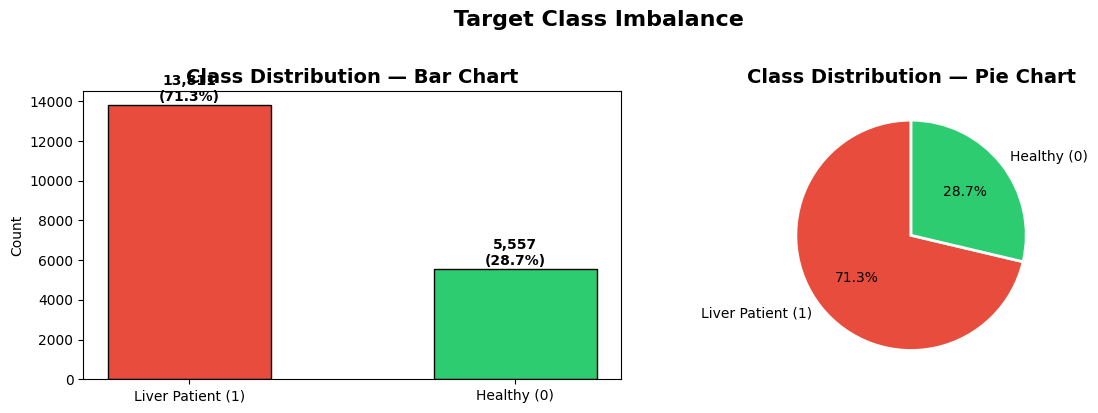


 Class Imbalance Ratio: 2.49:1  (Liver Patients : Healthy)
   → This imbalance MUST be addressed before training!


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
counts = df[TARGET].value_counts()
labels = ['Liver Patient (1)', 'Healthy (0)']
colors = ['#E74C3C', '#2ECC71']
# Bar chart
axes[0].bar(labels, counts.values, color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Class Distribution — Bar Chart', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(counts.values):
    axes[0].text(i, v + 200, f'{v:,}\n({v/len(df)*100:.1f}%)', ha='center', fontweight='bold')
# Pie chart
axes[1].pie(counts.values, labels=labels, autopct='%1.1f%%',
            colors=colors, startangle=90,
            wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Class Distribution — Pie Chart', fontsize=14, fontweight='bold')

plt.suptitle(' Target Class Imbalance', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()
print(f"\n Class Imbalance Ratio: {counts[1]/counts[0]:.2f}:1  (Liver Patients : Healthy)")
print(f"   → This imbalance MUST be addressed before training!")


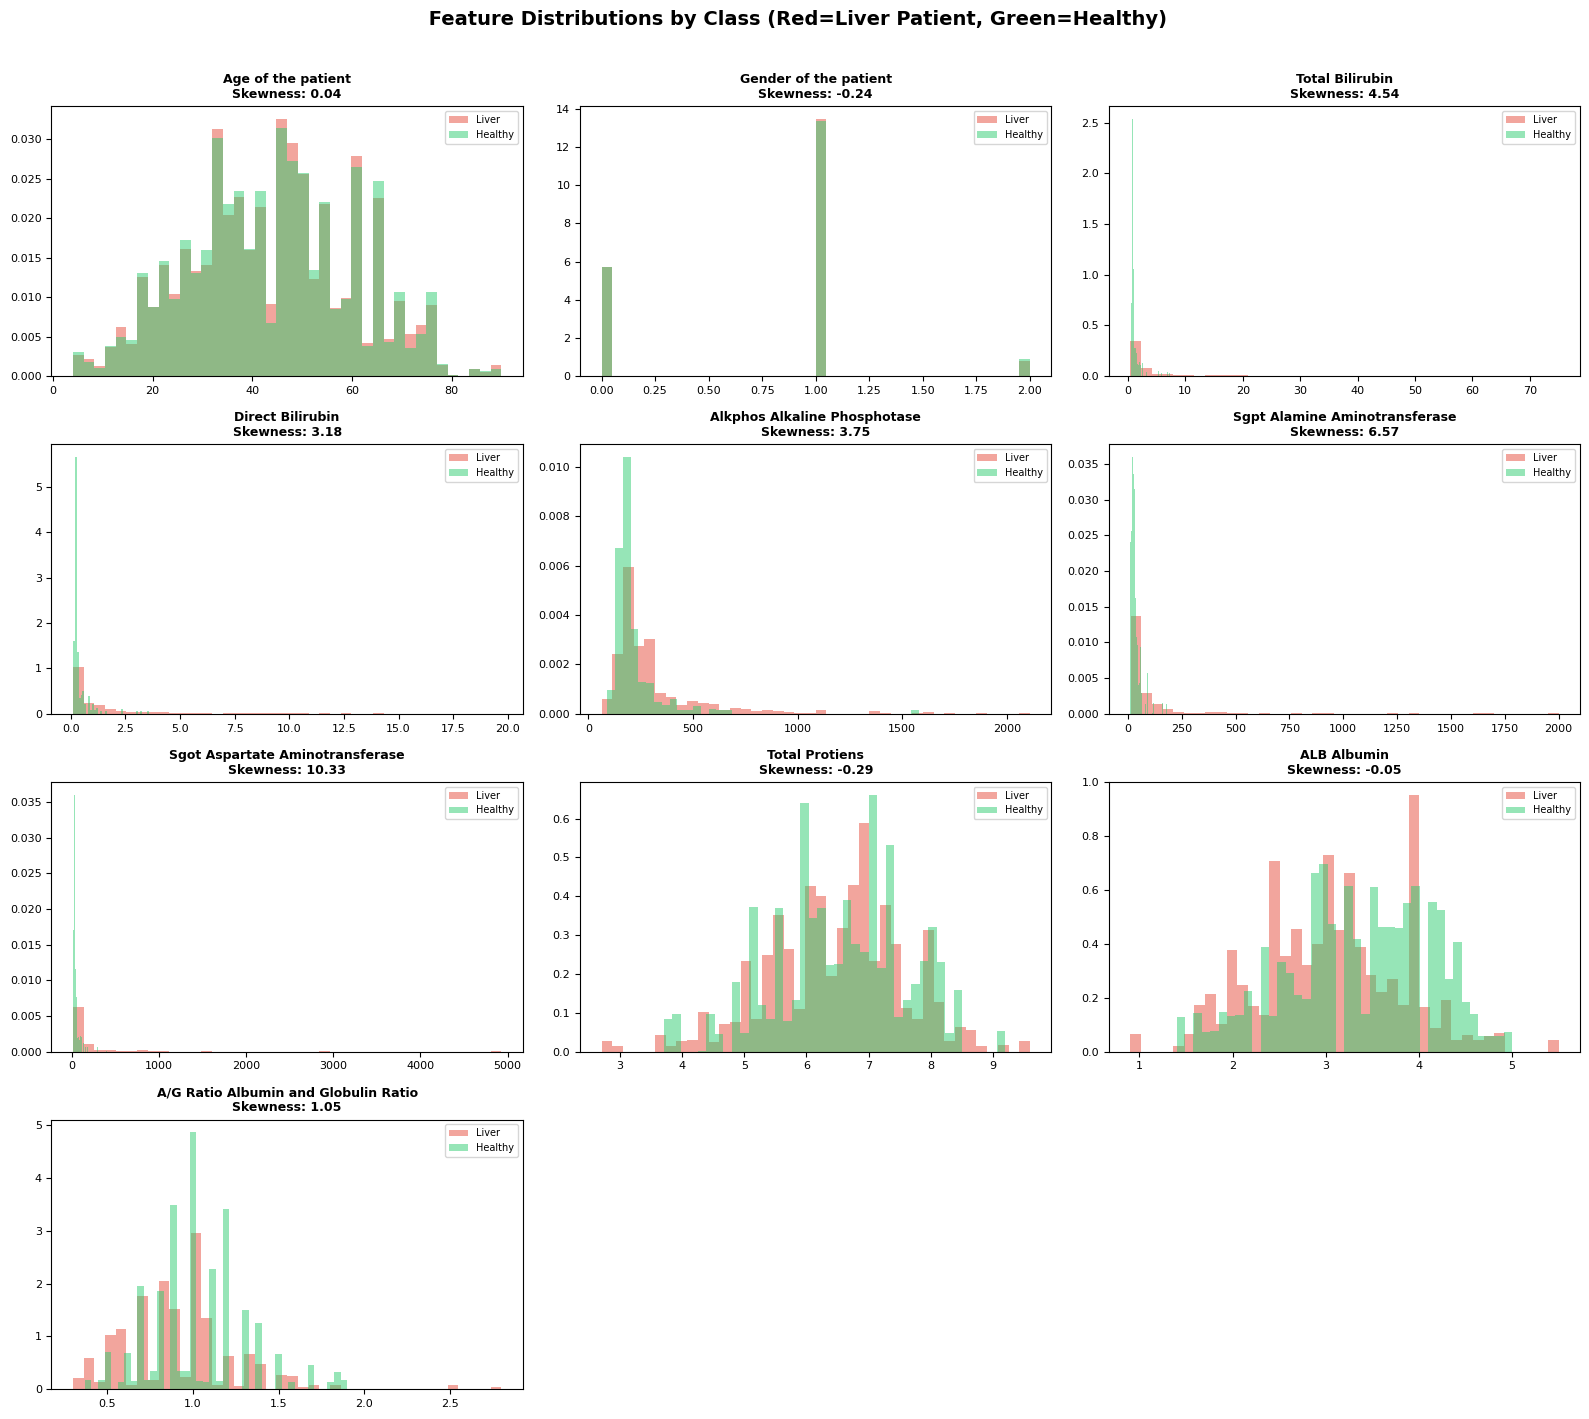


 Skewness Summary:
     HIGH SKEW  Sgot Aspartate Aminotransferase             skewness = +10.331
     HIGH SKEW  Sgpt Alamine Aminotransferase               skewness = +6.568
     HIGH SKEW  Total Bilirubin                             skewness = +4.538
     HIGH SKEW  Alkphos Alkaline Phosphotase                skewness = +3.748
     HIGH SKEW  Direct Bilirubin                            skewness = +3.178
     HIGH SKEW  A/G Ratio Albumin and Globulin Ratio        skewness = +1.053
     Total Protiens                              skewness = -0.293
     Gender of the patient                       skewness = -0.244
     ALB Albumin                                 skewness = -0.046
     Age of the patient                          skewness = +0.045


In [14]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
numerical_cols = [c for c in numerical_cols if c != TARGET]
n_cols = 3
n_rows = (len(numerical_cols) + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 3.5))
axes = axes.flatten()
skewness = {}
for i, col in enumerate(numerical_cols):
    ax = axes[i]
    skew_val = df[col].skew()
    skewness[col] = skew_val
    # Plot per class
    for label, color in zip([1, 0], ['#E74C3C', '#2ECC71']):
        subset = df[df[TARGET] == label][col].dropna()
        ax.hist(subset, bins=40, alpha=0.5, color=color,
                label=f'{"Liver" if label==1 else "Healthy"}', density=True)

    ax.set_title(f'{col}\nSkewness: {skew_val:.2f}', fontsize=9, fontweight='bold')
    ax.set_xlabel('')
    ax.legend(fontsize=7)
    ax.tick_params(labelsize=8)

# Hide unused subplots
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle(' Feature Distributions by Class (Red=Liver Patient, Green=Healthy)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print("\n Skewness Summary:")
for col, sk in sorted(skewness.items(), key=lambda x: abs(x[1]), reverse=True):
    flag = '  HIGH SKEW' if abs(sk) > 1 else ''
    print(f"   {flag}  {col:<42}  skewness = {sk:+.3f}")


### Apply Log Transformation to Highly Skewed Features

In [15]:
highly_skewed = [col for col, sk in skewness.items() if abs(sk) > 1]
print(f" Applying log1p transformation to {len(highly_skewed)} features:")
for col in highly_skewed:
    original_skew = df[col].skew()
    df[col] = np.log1p(df[col].clip(lower=0))   # clip negatives to 0 before log
    new_skew = df[col].skew()
    print(f"   • {col:<42}  {original_skew:+.2f}  →  {new_skew:+.2f}")

print("\n Log transformation complete.")


 Applying log1p transformation to 6 features:
   • Total Bilirubin                             +4.54  →  +1.70
   • Direct Bilirubin                            +3.18  →  +1.68
   • Alkphos Alkaline Phosphotase                +3.75  →  +1.30
   • Sgpt Alamine Aminotransferase               +6.57  →  +1.44
   • Sgot Aspartate Aminotransferase             +10.33  →  +1.19
   • A/G Ratio Albumin and Globulin Ratio        +1.05  →  +0.26

 Log transformation complete.


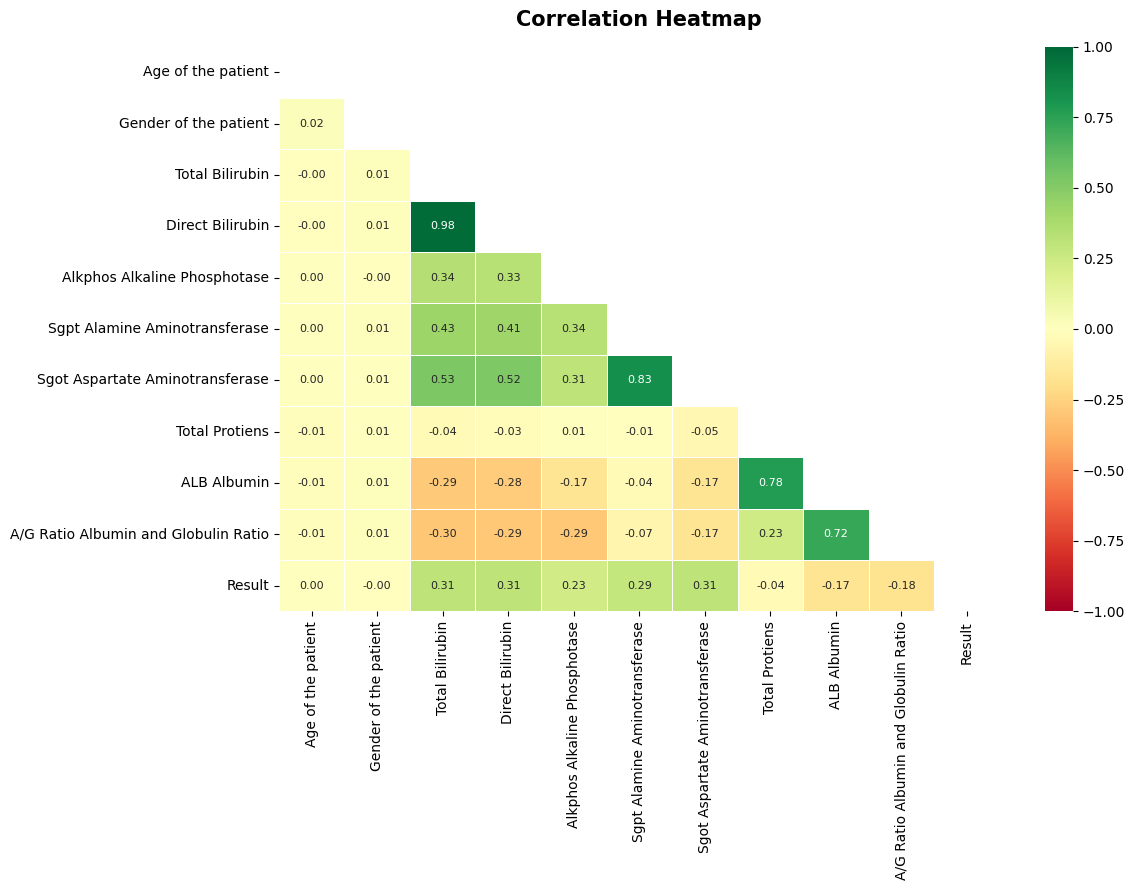


  Highly Correlated Feature Pairs (|r| > 0.85):
   • Direct Bilirubin ↔ Total Bilirubin  r = 0.977


In [ ]:
fig, ax = plt.subplots(figsize=(12, 9))
corr_matrix = df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(corr_matrix,mask=mask,annot=True,fmt='.2f',cmap='RdYlGn',center=0,linewidths=0.5,annot_kws={'size': 8},ax=ax,vmin=-1, vmax=1)

ax.set_title('Correlation Heatmap', fontsize=15, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()
# Highlight highly correlated pairs
print("\n  Highly Correlated Feature Pairs (|r| > 0.85):")
found = False
for i in range(len(corr_matrix.columns)):
    for j in range(i):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            print(f"   • {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}  "
                  f"r = {corr_matrix.iloc[i, j]:.3f}")
            found = True
if not found:
    print("   → No highly correlated pairs found (threshold=0.85). ")


---

## Data Preprocessing

### Pipeline Steps:
1. **KNN Imputer** — Fill missing values using the k-nearest neighbors
2. **Feature Selection** — Drop redundant or useless columns
3. **RobustScaler** — Scale features using the median and IQR (robust to outliers)

>  **Important:** The scaler will be fit ONLY on training data to prevent data leakage.


In [17]:
TARGET = 'Result'
X = df.drop(columns=[TARGET])
y = df[TARGET]

feature_names = X.columns.tolist()
print(f" Feature count : {len(feature_names)}")
print(f" Target        : {TARGET}")
print(f" Dataset size  : {X.shape[0]:,} samples")
print()
print("Features:")
for f in feature_names:
    print(f"  • {f}")


 Feature count : 10
 Target        : Result
 Dataset size  : 19,368 samples

Features:
  • Age of the patient
  • Gender of the patient
  • Total Bilirubin
  • Direct Bilirubin
  • Alkphos Alkaline Phosphotase
  • Sgpt Alamine Aminotransferase
  • Sgot Aspartate Aminotransferase
  • Total Protiens
  • ALB Albumin
  • A/G Ratio Albumin and Globulin Ratio


In [ ]:
# KNN Imputation 
print(f"Missing values BEFORE imputation:\n{X.isnull().sum()[X.isnull().sum() > 0]}")
print()

imputer = KNNImputer(n_neighbors=5)
X_imputed = pd.DataFrame(imputer.fit_transform(X), columns=feature_names)

print(f"Missing values AFTER imputation: {X_imputed.isnull().sum().sum()} ")
X = X_imputed.copy()


Missing values BEFORE imputation:
Age of the patient                        1
Total Bilirubin                         557
Direct Bilirubin                        490
Alkphos Alkaline Phosphotase            694
Sgpt Alamine Aminotransferase           459
Sgot Aspartate Aminotransferase         393
Total Protiens                          370
ALB Albumin                             413
A/G Ratio Albumin and Globulin Ratio    436
dtype: int64

Missing values AFTER imputation: 0 


---

##  Train-Test Split

We use **Stratified Split** to ensure both train and test sets preserve the same class ratio as the original dataset.

- **80% Training** — used for model learning
- **20% Testing** — held out for final evaluation

>  SMOTE and scaling are applied ONLY to training data (inside the training loop) to prevent data leakage.


In [19]:
# Stratified train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y          
)

print(" Split Summary:")
print(f"   Training set   : {X_train.shape[0]:,} samples")
print(f"   Test set       : {X_test.shape[0]:,} samples")
print()
print(" Class distribution in TRAIN set:")
train_counts = y_train.value_counts()
for cls, cnt in train_counts.items():
    print(f"   Class {cls}: {cnt:,}  ({cnt/len(y_train)*100:.1f}%)")
print()
print(" Class distribution in TEST set:")
test_counts = y_test.value_counts()
for cls, cnt in test_counts.items():
    print(f"   Class {cls}: {cnt:,}  ({cnt/len(y_test)*100:.1f}%)")


 Split Summary:
   Training set   : 15,494 samples
   Test set       : 3,874 samples

 Class distribution in TRAIN set:
   Class 1: 11,049  (71.3%)
   Class 0: 4,445  (28.7%)

 Class distribution in TEST set:
   Class 1: 2,762  (71.3%)
   Class 0: 1,112  (28.7%)


#### Initialize Scaler

In [20]:
# RobustScaler is preferred when data has outliers
scaler = RobustScaler()
X_train_scaled = scaler.fit_transform(X_train)     
X_test_scaled  = scaler.transform(X_test)         
print(" RobustScaler fitted on training data only.")
print("   → Prevents data leakage from test set.")


 RobustScaler fitted on training data only.
   → Prevents data leakage from test set.


---

##  Handle Class Imbalance

We compare **three strategies** for handling imbalance:

| Strategy | Description |
|----------|-------------|
| **No Balancing** | Train on original imbalanced data |
| **SMOTE** | Synthetic Minority Over-Sampling — creates new synthetic minority samples |
| **Undersampling** | Randomly reduce majority class to match minority class |


In [21]:
#  SMOTE (Oversampling) 
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train_scaled, y_train)

print(" After SMOTE (Oversampling):")
for cls, cnt in pd.Series(y_train_smote).value_counts().items():
    print(f"   Class {cls}: {cnt:,}  ({cnt/len(y_train_smote)*100:.1f}%)")
print(f"   Total : {len(y_train_smote):,} samples")


 After SMOTE (Oversampling):
   Class 1: 11,049  (50.0%)
   Class 0: 11,049  (50.0%)
   Total : 22,098 samples


In [22]:
#  Random Undersampling 
undersample = RandomUnderSampler(random_state=42)
X_train_under, y_train_under = undersample.fit_resample(X_train_scaled, y_train)

print(" After Undersampling:")
for cls, cnt in pd.Series(y_train_under).value_counts().items():
    print(f"   Class {cls}: {cnt:,}  ({cnt/len(y_train_under)*100:.1f}%)")
print(f"   Total : {len(y_train_under):,} samples")


 After Undersampling:
   Class 0: 4,445  (50.0%)
   Class 1: 4,445  (50.0%)
   Total : 8,890 samples


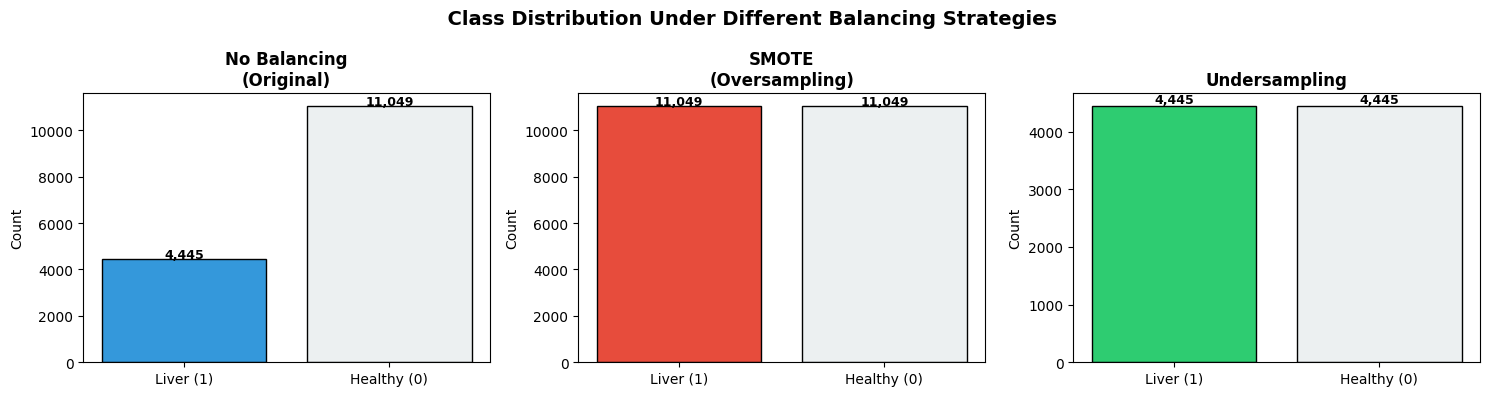

In [23]:
#  Visualize Balancing Strategies 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
datasets = [
    (y_train,          'No Balancing\n(Original)',   '#3498DB'),
    (y_train_smote,    'SMOTE\n(Oversampling)',      '#E74C3C'),
    (y_train_under,    'Undersampling',              '#2ECC71'),]
for ax, (y_data, title, color) in zip(axes, datasets):
    counts = pd.Series(y_data).value_counts().sort_index()
    bars = ax.bar(['Liver (1)', 'Healthy (0)'], counts.values,color=[color, '#ECF0F1'], edgecolor='black')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_ylabel('Count')
    for bar, val in zip(bars, counts.values):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,f'{val:,}', ha='center', fontsize=9, fontweight='bold')

plt.suptitle('  Class Distribution Under Different Balancing Strategies',fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

##  Model Training

We train **3 model families** × **3 balancing strategies** = **9 combinations**, plus class-weight variants.

### Models:
| Model | Why chosen |
|-------|-----------|
| **Logistic Regression** | Fast, interpretable baseline |
| **Random Forest** | Handles non-linearity, robust to outliers |
| **XGBoost** | Gradient boosting, often best performer on tabular data |

### Hyperparameter Tuning:
- **GridSearchCV** with **Stratified 5-Fold Cross Validation**
- Optimizing for **F1 score** (balances recall and precision)


In [ ]:
#  Define Cross Validation Strategy 
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
#  Evaluate a Model 
def evaluate_model(model, X_tr, y_tr, X_te, y_te, label=''):
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    
    return {
        'Label'    : label,
        'Accuracy' : accuracy_score(y_te, y_pred),
        'Precision': precision_score(y_te, y_pred, zero_division=0),
        'Recall'   : recall_score(y_te, y_pred, zero_division=0),
        'F1'       : f1_score(y_te, y_pred, zero_division=0),
        'ROC-AUC'  : roc_auc_score(y_te, y_prob),
        'model'    : model,
        'y_pred'   : y_pred,
        'y_prob'   : y_prob, }


### Logistic Regression

In [25]:
from sklearn.model_selection import GridSearchCV
lr_params = {'C': [0.01, 0.1, 1, 10], 'solver': ['lbfgs', 'liblinear']}
lr_results = []

for X_tr, y_tr, tag in [
    (X_train_scaled,  y_train,        'LR — No Balance'),
    (X_train_smote,   y_train_smote,  'LR — SMOTE'),
    (X_train_under,   y_train_under,  'LR — Undersample'),
]:
    gs = GridSearchCV(
        LogisticRegression(max_iter=1000, random_state=42),
        lr_params, cv=cv, scoring='f1', n_jobs=-1
    )
    gs.fit(X_tr, y_tr)
    res = evaluate_model(gs.best_estimator_, X_tr, y_tr, X_test_scaled, y_test, label=tag)
    res['Best Params'] = str(gs.best_params_)
    lr_results.append(res)
    print(f"   {tag:<30} | Recall={res['Recall']:.3f}  F1={res['F1']:.3f}")

# Class-weight version
gs_cw = GridSearchCV(
    LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42),
    lr_params, cv=cv, scoring='f1', n_jobs=-1)
gs_cw.fit(X_train_scaled, y_train)
res_cw = evaluate_model(gs_cw.best_estimator_, X_train_scaled, y_train,X_test_scaled, y_test, label='LR — Class Weight')
res_cw['Best Params'] = str(gs_cw.best_params_)
lr_results.append(res_cw)
print(f"   {'LR — Class Weight':<30} | Recall={res_cw['Recall']:.3f}  F1={res_cw['F1']:.3f}")

print("\n Logistic Regression tuning complete.")


   LR — No Balance                | Recall=0.907  F1=0.825
   LR — SMOTE                     | Recall=0.594  F1=0.716
   LR — Undersample               | Recall=0.592  F1=0.715
   LR — Class Weight              | Recall=0.597  F1=0.716

 Logistic Regression tuning complete.


### Random Forest

In [26]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]}

rf_results = []

for X_tr, y_tr, tag in [
    (X_train_scaled,  y_train,        'RF — No Balance'),
    (X_train_smote,   y_train_smote,  'RF — SMOTE'),
    (X_train_under,   y_train_under,  'RF — Undersample'),
]:
    gs = GridSearchCV(
        RandomForestClassifier(random_state=42, n_jobs=-1),
        rf_params, cv=cv, scoring='f1', n_jobs=-1
    )
    gs.fit(X_tr, y_tr)
    res = evaluate_model(gs.best_estimator_, X_tr, y_tr,
                         X_test_scaled, y_test, label=tag)
    res['Best Params'] = str(gs.best_params_)
    rf_results.append(res)
    print(f"   {tag:<30} | Recall={res['Recall']:.3f}  F1={res['F1']:.3f}")

# Class-weight version
gs_cw = GridSearchCV(
    RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
    rf_params, cv=cv, scoring='f1', n_jobs=-1
)
gs_cw.fit(X_train_scaled, y_train)
res_cw = evaluate_model(gs_cw.best_estimator_, X_train_scaled, y_train,
                        X_test_scaled, y_test, label='RF — Class Weight')
res_cw['Best Params'] = str(gs_cw.best_params_)
rf_results.append(res_cw)
print(f"   {'RF — Class Weight':<30} | Recall={res_cw['Recall']:.3f}  F1={res_cw['F1']:.3f}")

   RF — No Balance                | Recall=0.999  F1=0.997
   RF — SMOTE                     | Recall=0.997  F1=0.997
   RF — Undersample               | Recall=0.998  F1=0.997
   RF — Class Weight              | Recall=0.999  F1=0.997


### XGBoost

In [27]:
# Calculate scale_pos_weight for XGBoost's built-in imbalance handling
scale_pw = (y_train == 0).sum() / (y_train == 1).sum()

xgb_params = {
    'n_estimators': [100, 200],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.05, 0.1]}

xgb_results = []

for X_tr, y_tr, tag in [
    (X_train_scaled,  y_train,        'XGB — No Balance'),
    (X_train_smote,   y_train_smote,  'XGB — SMOTE'),
    (X_train_under,   y_train_under,  'XGB — Undersample'),
]:
    gs = GridSearchCV(
        XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42, n_jobs=-1),xgb_params, cv=cv, scoring='f1', n_jobs=-1)
    gs.fit(X_tr, y_tr)
    res = evaluate_model(gs.best_estimator_, X_tr, y_tr,
                         X_test_scaled, y_test, label=tag)
    res['Best Params'] = str(gs.best_params_)
    xgb_results.append(res)
    print(f"   {tag:<30} | Recall={res['Recall']:.3f}  F1={res['F1']:.3f}")

# scale_pos_weight version
gs_spw = GridSearchCV(
    XGBClassifier(scale_pos_weight=scale_pw, use_label_encoder=False,
                  eval_metric='logloss', random_state=42, n_jobs=-1),
    xgb_params, cv=cv, scoring='f1', n_jobs=-1
)
gs_spw.fit(X_train_scaled, y_train)
res_spw = evaluate_model(gs_spw.best_estimator_, X_train_scaled, y_train,
                         X_test_scaled, y_test, label='XGB — scale_pos_weight')
res_spw['Best Params'] = str(gs_spw.best_params_)
xgb_results.append(res_spw)
print(f"   {'XGB — scale_pos_weight':<30} | Recall={res_spw['Recall']:.3f}  F1={res_spw['F1']:.3f}")

   XGB — No Balance               | Recall=0.999  F1=0.997
   XGB — SMOTE                    | Recall=0.997  F1=0.997
   XGB — Undersample              | Recall=0.997  F1=0.997
   XGB — scale_pos_weight         | Recall=0.999  F1=0.998


---

##  Model Evaluation

For each model we compute:
- **Accuracy, Precision, Recall, F1, ROC-AUC**
- **Confusion Matrix** — visualize TP, TN, FP, FN
- **ROC Curve** — trade-off between TPR and FPR


In [ ]:
#  Combine All Results 
all_results = lr_results + rf_results + xgb_results
metrics_cols = ['Label', 'Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
results_df = pd.DataFrame(all_results)[metrics_cols].copy()
results_df = results_df.sort_values('Recall', ascending=False).reset_index(drop=True)

print(" All Models — Sorted by Recall (most important metric):\n")
display(results_df.style
    .background_gradient(cmap='RdYlGn', subset=['Accuracy','Precision','Recall','F1','ROC-AUC'])
    .format({'Accuracy': '{:.3f}', 'Precision': '{:.3f}','Recall': '{:.3f}', 'F1': '{:.3f}', 'ROC-AUC': '{:.3f}'}).set_properties(**{'font-size': '12px'}))


 All Models — Sorted by Recall (most important metric):



,Label,Accuracy,Precision,Recall,F1,ROC-AUC
0,RF — Class Weight,0.996,0.996,0.999,0.997,0.999
1,XGB — No Balance,0.996,0.995,0.999,0.997,0.999
2,RF — No Balance,0.996,0.995,0.999,0.997,0.999
3,XGB — scale_pos_weight,0.997,0.997,0.999,0.998,0.999
4,RF — Undersample,0.996,0.997,0.998,0.997,1.000
5,RF — SMOTE,0.996,0.997,0.997,0.997,0.999
6,XGB — SMOTE,0.996,0.997,0.997,0.997,0.999
7,XGB — Undersample,0.996,0.998,0.997,0.997,0.999
8,LR — No Balance,0.726,0.757,0.907,0.825,0.773
9,LR — Class Weight,0.663,0.894,0.597,0.716,0.771


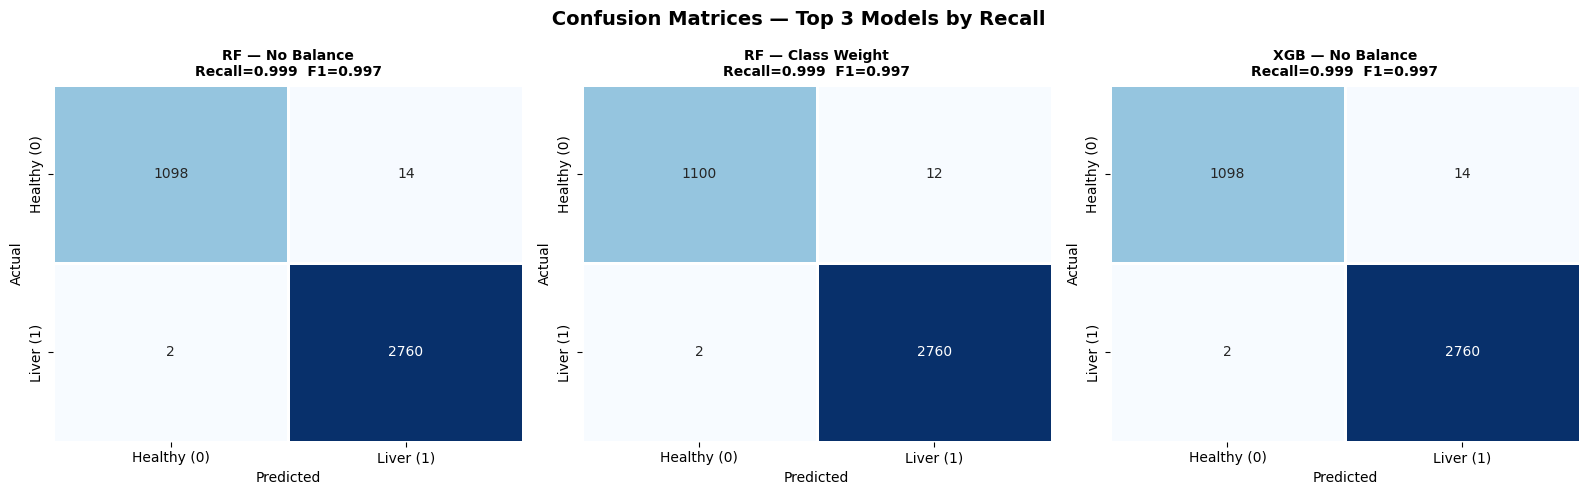

In [ ]:
#  Best 3 Models — Confusion Matrices 
top3 = results_df.head(3)['Label'].tolist()
top3_results = [r for r in all_results if r['Label'] in top3]

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, res in zip(axes, top3_results):
    cm = confusion_matrix(y_test, res['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Healthy (0)', 'Liver (1)'],
                yticklabels=['Healthy (0)', 'Liver (1)'],
                ax=ax, cbar=False, linewidths=1)
    ax.set_title(f"{res['Label']}\nRecall={res['Recall']:.3f}  F1={res['F1']:.3f}",
                 fontsize=10, fontweight='bold')
    ax.set_xlabel('Predicted', fontsize=10)
    ax.set_ylabel('Actual', fontsize=10)

plt.suptitle(' Confusion Matrices — Top 3 Models by Recall',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


### ROC Curves — All Models

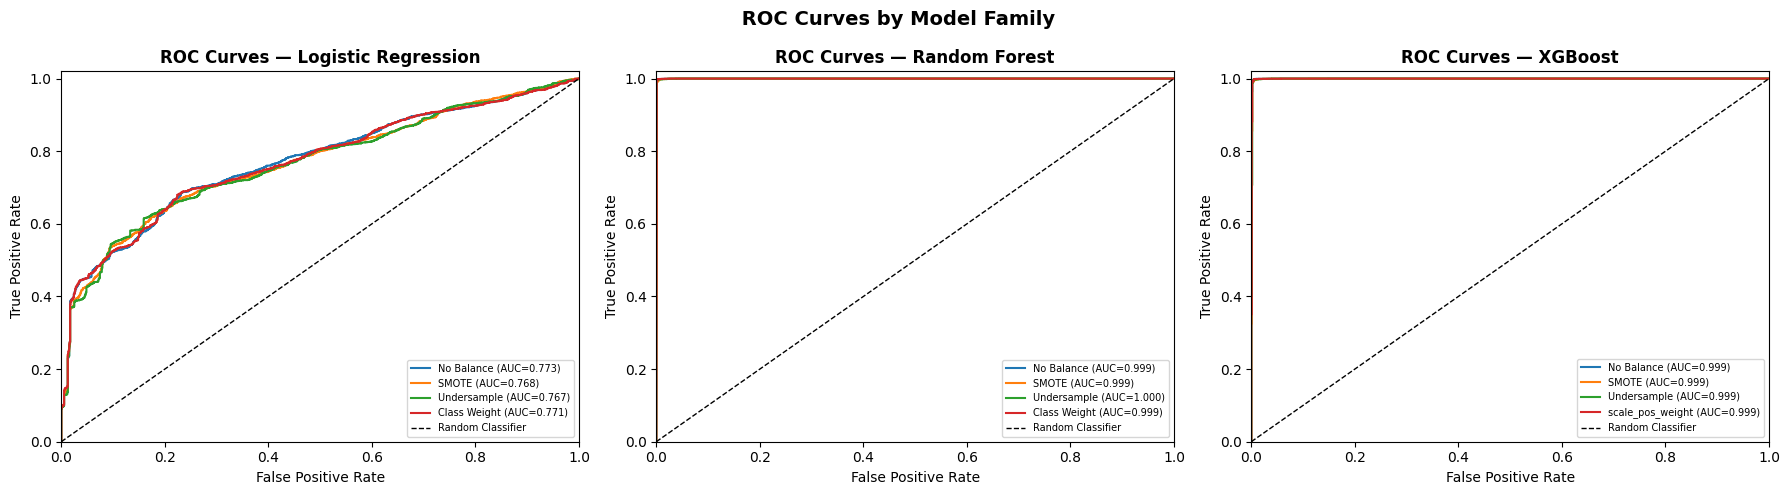

In [30]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_groups = [
    (lr_results,  'Logistic Regression',  axes[0]),
    (rf_results,  'Random Forest',        axes[1]),
    (xgb_results, 'XGBoost',              axes[2]),]

for results, title, ax in model_groups:
    for res in results:
        fpr, tpr, _ = roc_curve(y_test, res['y_prob'])
        ax.plot(fpr, tpr, label=f"{res['Label'].split('—')[-1].strip()} (AUC={res['ROC-AUC']:.3f})")
    ax.plot([0,1],[0,1],'k--', linewidth=1, label='Random Classifier')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curves — {title}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.set_xlim([0, 1])
    ax.set_ylim([0, 1.02])

plt.suptitle(' ROC Curves by Model Family', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

##  Learning Curves

Learning curves show how model performance changes with increasing training data.

- **Overfitting**: training score >> validation score
- **Underfitting**: both scores are low
- **Good fit**: both scores converge at a high value


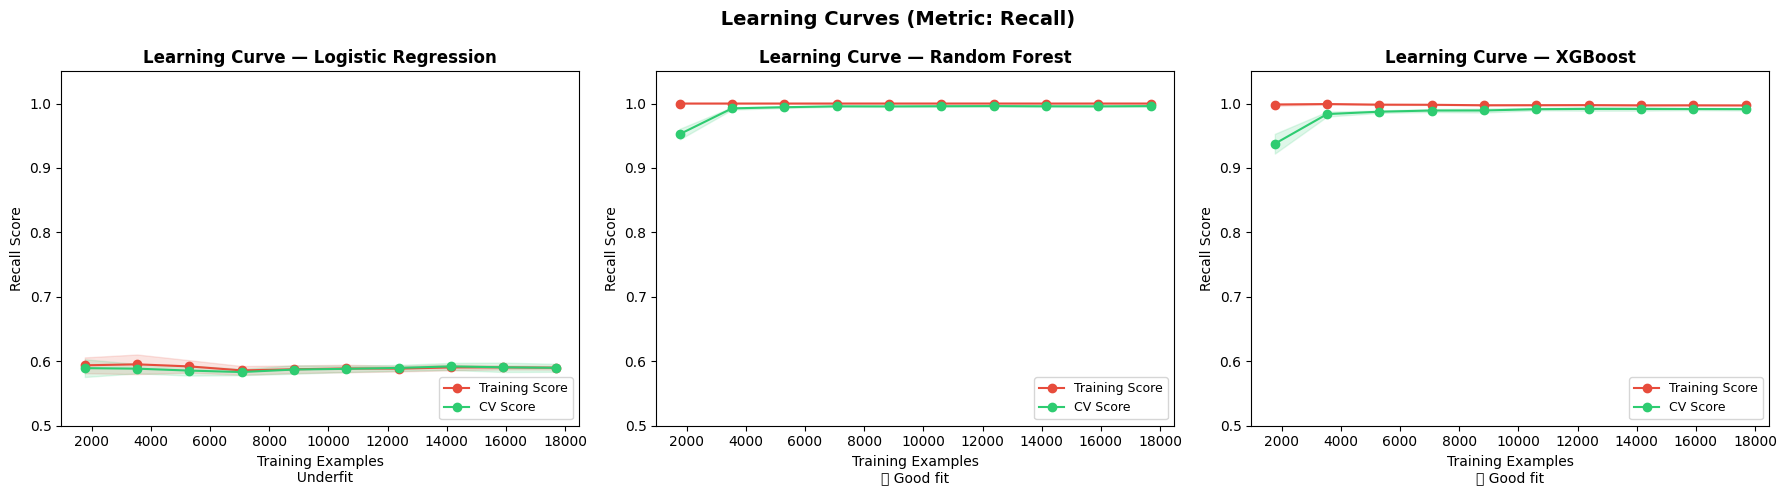

In [31]:
def get_best(results_list):
    return max(results_list, key=lambda r: r['F1'])['model']

best_lr  = get_best(lr_results)
best_rf  = get_best(rf_results)
best_xgb = get_best(xgb_results)

models_lc = [
    ('Logistic Regression', best_lr),
    ('Random Forest',        best_rf),
    ('XGBoost',              best_xgb),
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
train_sizes = np.linspace(0.1, 1.0, 10)

for ax, (name, model) in zip(axes, models_lc):
    train_sz, train_sc, val_sc = learning_curve(
        model,
        X_train_smote, y_train_smote,   
        cv=cv,
        scoring='recall',
        train_sizes=train_sizes,
        n_jobs=-1,
        shuffle=True,
        random_state=42
    )
    
    train_mean = train_sc.mean(axis=1)
    train_std  = train_sc.std(axis=1)
    val_mean   = val_sc.mean(axis=1)
    val_std    = val_sc.std(axis=1)
    
    ax.fill_between(train_sz, train_mean - train_std, train_mean + train_std,
                    alpha=0.15, color='#E74C3C')
    ax.fill_between(train_sz, val_mean - val_std, val_mean + val_std,
                    alpha=0.15, color='#2ECC71')
    
    ax.plot(train_sz, train_mean, 'o-', color='#E74C3C', label='Training Score')
    ax.plot(train_sz, val_mean,   'o-', color='#2ECC71', label='CV Score')
    
    ax.set_title(f'Learning Curve — {name}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Training Examples')
    ax.set_ylabel('Recall Score')
    ax.legend(loc='lower right', fontsize=9)
    ax.set_ylim([0.5, 1.05])
    
    gap = train_mean[-1] - val_mean[-1]
    diagnosis = '  Overfit' if gap > 0.1 else ('  Underfit' if val_mean[-1] < 0.7 else '✅ Good fit')
    ax.set_xlabel(f'Training Examples\n{diagnosis}', fontsize=10)

plt.suptitle(' Learning Curves (Metric: Recall)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

##  Model Comparison

We compare all models in a single visualization and select the best one based on **Recall** and **F1-Score**.



 Best Model (by Recall): RF — Class Weight
   Recall   = 0.9993
   F1-Score = 0.9975
   ROC-AUC  = 0.9994


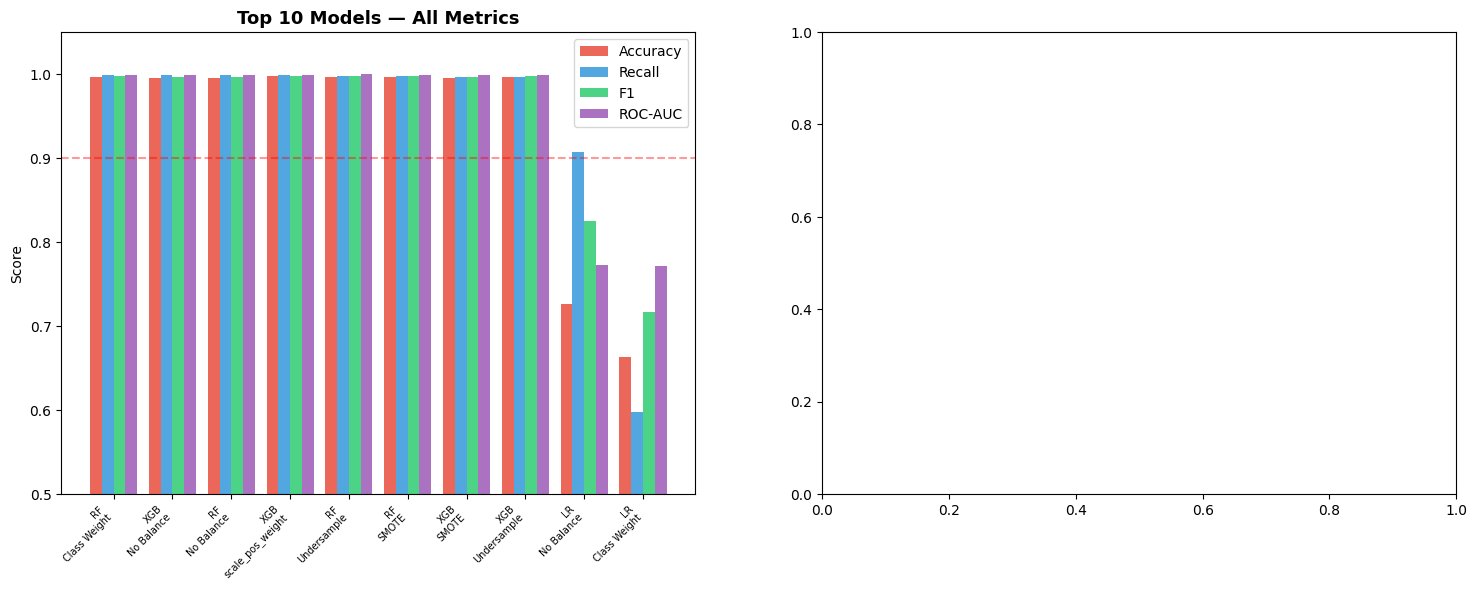

In [78]:
top10 = results_df.head(10).copy()
fig, axes = plt.subplots(1,2, figsize=(18, 6))

metric_colors = {
    'Recall'  : '#E74C3C',
    'F1'      : '#3498DB',
    'ROC-AUC' : '#2ECC71',
    'Accuracy': '#9B59B6',}

x = np.arange(len(top10))
width = 0.2
metrics_to_plot = ['Accuracy', 'Recall', 'F1', 'ROC-AUC']

for i, metric in enumerate(metrics_to_plot):
    axes[0].bar(x + i * width, top10[metric], width,
                label=metric, color=list(metric_colors.values())[i], alpha=0.85)

axes[0].set_xticks(x + 1.5 * width)
axes[0].set_xticklabels(
    [l.replace(' — ', '\n') for l in top10['Label']],
    fontsize=7, rotation=45, ha='right'
)
axes[0].set_ylim([0.5, 1.05])
axes[0].set_title('Top 10 Models — All Metrics', fontsize=13, fontweight='bold')
axes[0].legend()
axes[0].set_ylabel('Score')
axes[0].axhline(y=0.9, color='red', linestyle='--', alpha=0.4, label='0.9 threshold')
best_model_label = results_df.iloc[0]['Label']
print(f"\n Best Model (by Recall): {best_model_label}")
print(f"   Recall   = {results_df.iloc[0]['Recall']:.4f}")
print(f"   F1-Score = {results_df.iloc[0]['F1']:.4f}")
print(f"   ROC-AUC  = {results_df.iloc[0]['ROC-AUC']:.4f}")


---

##  Stacking Ensemble

We combine the best models into a **Stacking Classifier** — an ensemble method where predictions from base models are fed as features to a meta-learner (Logistic Regression).

```
Base Models: [Logistic Regression, Random Forest, XGBoost]  --> Meta-Learner: Logistic Regression
```


### Build Stacking Ensemble

In [33]:

estimators = [
    ('lr',  best_lr),
    ('rf',  best_rf),
    ('xgb', best_xgb),
]

stacking = StackingClassifier(
    estimators=estimators,
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=5,
    n_jobs=-1
)

stacking.fit(X_train_smote, y_train_smote)

stacking_pred = stacking.predict(X_test_scaled)
stacking_prob = stacking.predict_proba(X_test_scaled)[:, 1]

stacking_metrics = {
    'Label'    : ' Stacking Ensemble',
    'Accuracy' : accuracy_score(y_test, stacking_pred),
    'Precision': precision_score(y_test, stacking_pred, zero_division=0),
    'Recall'   : recall_score(y_test, stacking_pred, zero_division=0),
    'F1'       : f1_score(y_test, stacking_pred, zero_division=0),
    'ROC-AUC'  : roc_auc_score(y_test, stacking_prob),
}

print("\n Stacking Ensemble Results:")
for metric, val in stacking_metrics.items():
    if metric != 'Label':
        print(f"   {metric:<12}: {val:.4f}")

# Compare stacking vs best individual model
print(f"\n Stacking vs Best Individual Model:")
print(f"   Metric    | Best Individual | Stacking")
print(f"   ----------|-----------------|----------")
for metric in ['Recall', 'F1', 'ROC-AUC']:
    indiv = results_df.iloc[0][metric]
    stack = stacking_metrics[metric]
    delta = stack - indiv
    arrow = '⬆️ ' if delta > 0 else '⬇️ '
    print(f"   {metric:<10}| {indiv:.4f}          | {stack:.4f}  {arrow} ({delta:+.4f})")


[13:56:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[13:56:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[13:56:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[13:56:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

[13:56:18] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.




 Stacking Ensemble Results:
   Accuracy    : 0.9961
   Precision   : 0.9967
   Recall      : 0.9978
   F1          : 0.9973
   ROC-AUC     : 0.9994

 Stacking vs Best Individual Model:
   Metric    | Best Individual | Stacking
   ----------|-----------------|----------
   Recall    | 0.9993          | 0.9978  ⬇️  (-0.0014)
   F1        | 0.9975          | 0.9973  ⬇️  (-0.0002)
   ROC-AUC   | 0.9994          | 0.9994  ⬇️  (-0.0000)


### Confusion Matrix for Stacking

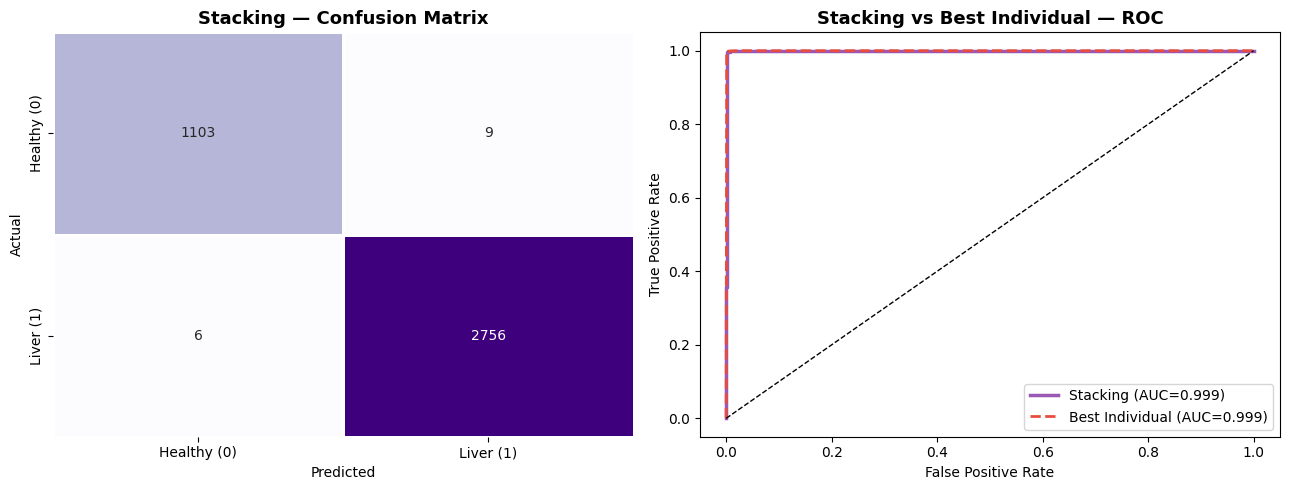

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

cm = confusion_matrix(y_test, stacking_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Healthy (0)', 'Liver (1)'],
            yticklabels=['Healthy (0)', 'Liver (1)'],
            ax=axes[0], linewidths=1, cbar=False)
axes[0].set_title('Stacking — Confusion Matrix', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

fpr_s, tpr_s, _ = roc_curve(y_test, stacking_prob)
axes[1].plot(fpr_s, tpr_s, color='#9B59B6', linewidth=2.5,label=f'Stacking (AUC={stacking_metrics["ROC-AUC"]:.3f})')
for res in [r for r in all_results if r['Label'] == results_df.iloc[0]['Label']]:
    fpr_b, tpr_b, _ = roc_curve(y_test, res['y_prob'])
    axes[1].plot(fpr_b, tpr_b, '--', color='#E74C3C', linewidth=2, label=f'Best Individual (AUC={res["ROC-AUC"]:.3f})')
axes[1].plot([0,1],[0,1],'k--', linewidth=1)
axes[1].set_title('Stacking vs Best Individual — ROC', fontsize=13, fontweight='bold')
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].legend()

plt.tight_layout()
plt.show()


---

## Model Interpretability — SHAP

**SHAP (SHapley Additive exPlanations)** explains each prediction by computing how much each feature contributed to moving the prediction away from the base value.

### Why SHAP?
- Model-agnostic (works for any ML model)
- Provides both **global** (dataset-wide) and **local** (single-prediction) explanations
- Based on solid game-theory foundations


### SHAP Setup

In [35]:
# Use XGBoost best model (TreeExplainer is most efficient for tree models)
best_xgb_model = get_best(xgb_results)

explainer = shap.TreeExplainer(best_xgb_model)

# Use a sample for speed (SHAP can be slow on large datasets)
sample_size = min(2000, len(X_test_scaled))
X_sample = X_test_scaled[:sample_size]

print(f" Computing SHAP values on {sample_size} test samples")
shap_values = explainer.shap_values(X_sample)
print(" SHAP values computed!")

# Handle binary output format (some versions return [neg_class, pos_class])
if isinstance(shap_values, list):
    shap_vals = shap_values[1]
else:
    shap_vals = shap_values

print(f"   SHAP values shape: {np.array(shap_vals).shape}")


 Computing SHAP values on 2000 test samples
 SHAP values computed!
   SHAP values shape: (2000, 10)


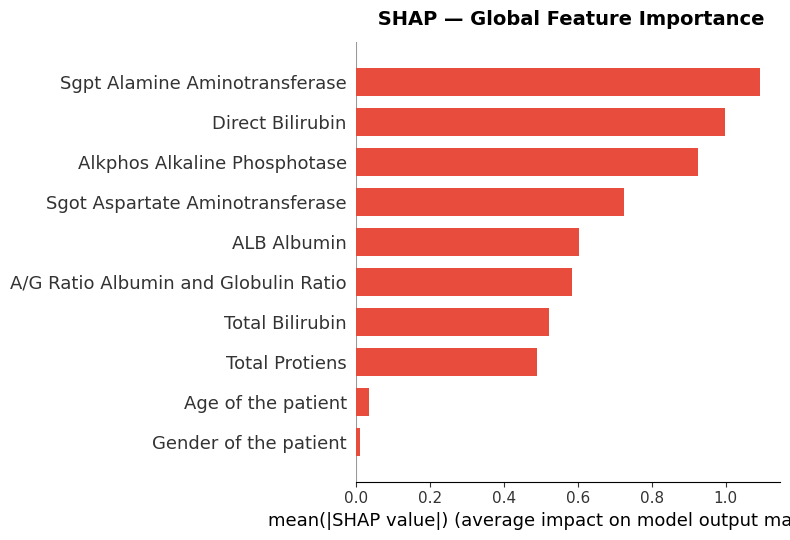

In [36]:
# Global Explanation: Summary Plot
plt.figure(figsize=(10, 7))
shap.summary_plot(
    shap_vals,
    X_sample,
    feature_names=feature_names,
    plot_type='bar',
    show=False,
    color='#E74C3C'
)
plt.title(' SHAP — Global Feature Importance', fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()


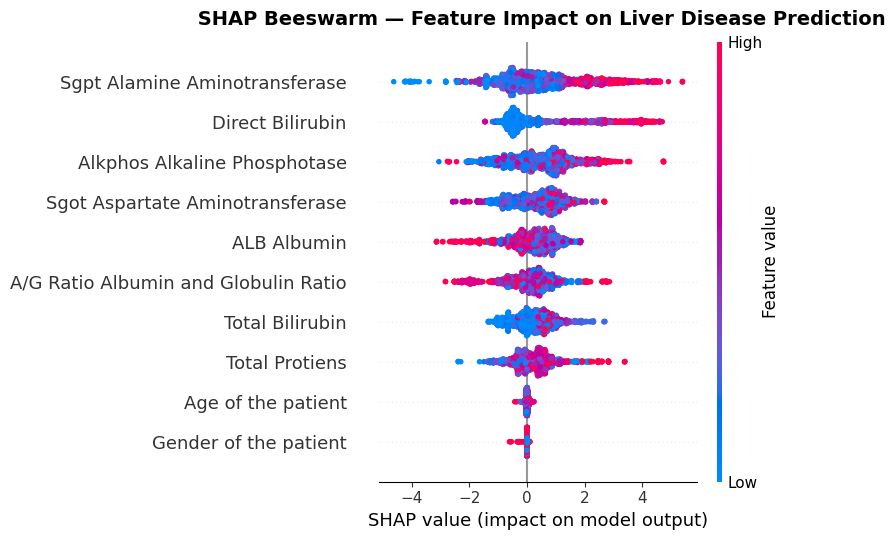

How to Read the Beeswarm Plot:
  Each dot = one patient prediction
  Position on X-axis = SHAP value (positive = toward Liver Patient)
  Color = feature value (Red = High value, Blue = Low value)
  Width = density of points at that SHAP value


In [37]:
#  Beeswarm Plot (Feature Impact Distribution) 
plt.figure(figsize=(11, 7))
shap.summary_plot(
    shap_vals,
    X_sample,
    feature_names=feature_names,
    show=False,
    max_display=10
)
plt.title(' SHAP Beeswarm — Feature Impact on Liver Disease Prediction',
          fontsize=14, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

print("How to Read the Beeswarm Plot:")
print("  Each dot = one patient prediction")
print("  Position on X-axis = SHAP value (positive = toward Liver Patient)")
print("  Color = feature value (Red = High value, Blue = Low value)")
print("  Width = density of points at that SHAP value")


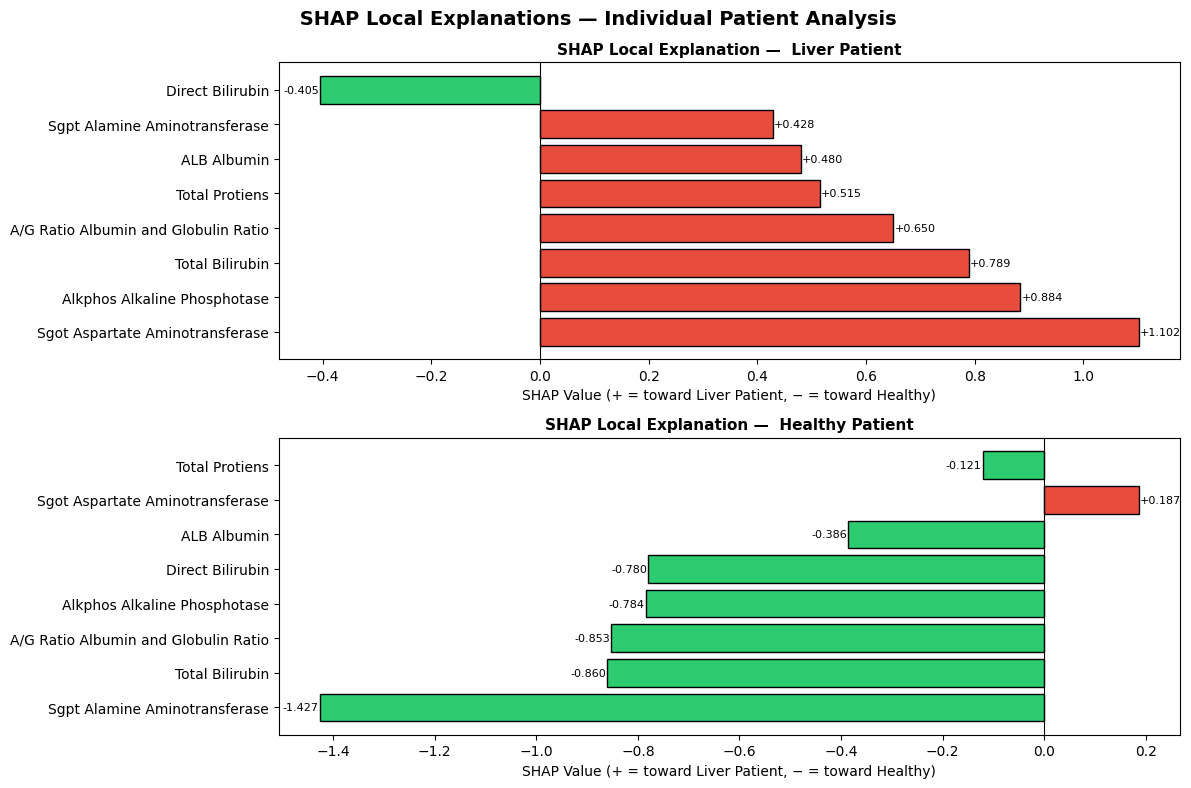

In [38]:
# ── Local Explanation: Single Patient ───────────────────────
# Pick one liver patient and one healthy patient
y_test_arr = np.array(y_test)
liver_idx   = np.where(y_test_arr[:sample_size] == 1)[0][0]
healthy_idx = np.where(y_test_arr[:sample_size] == 0)[0][0]

fig, axes = plt.subplots(2, 1, figsize=(12, 8))

for ax, idx, label in [
    (axes[0], liver_idx,   ' Liver Patient'),
    (axes[1], healthy_idx, ' Healthy Patient'),
]:
    sv = np.array(shap_vals[idx])
    sorted_idx = np.argsort(np.abs(sv))[::-1][:8]
    feat_names_sorted = [feature_names[i] for i in sorted_idx]
    shap_sorted = sv[sorted_idx]
    colors = ['#E74C3C' if v > 0 else '#2ECC71' for v in shap_sorted]
    
    bars = ax.barh(feat_names_sorted, shap_sorted, color=colors, edgecolor='black')
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(f'SHAP Local Explanation — {label}', fontsize=11, fontweight='bold')
    ax.set_xlabel('SHAP Value (+ = toward Liver Patient, − = toward Healthy)')
    
    for bar, val in zip(bars, shap_sorted):
        ax.text(val + (0.002 if val > 0 else -0.002), bar.get_y() + bar.get_height()/2,
                f'{val:+.3f}', va='center', ha='left' if val > 0 else 'right', fontsize=8)

plt.suptitle(' SHAP Local Explanations — Individual Patient Analysis',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


---

##  Save Final Model

We save the **best model**, **scaler**, and **feature names** using `joblib` for deployment.

```
model.pkl    → Best trained model (RF or Stacking)
scaler.pkl   → Fitted RobustScaler
features.pkl → List of feature names
```


In [39]:
best_individual_recall = results_df.iloc[0]['Recall']
stacking_recall = stacking_metrics['Recall']

if stacking_recall >= best_individual_recall:
    final_model = stacking
    final_model_name = 'Stacking Ensemble'
else:
    final_model = get_best(xgb_results)   
    final_model_name = results_df.iloc[0]['Label']

print(f" Final Model Selected: {final_model_name}")
print(f"   Recall = {max(stacking_recall, best_individual_recall):.4f}")


 Final Model Selected: RF — Class Weight
   Recall = 0.9993


In [40]:
import os
save_dir = 'saved_pipelinev3'
os.makedirs(save_dir, exist_ok=True)
# Save model
joblib.dump(final_model,  f'{save_dir}/model.pkl')
# Save scaler
joblib.dump(scaler,       f'{save_dir}/scaler.pkl')
# Save feature names
joblib.dump(feature_names, f'{save_dir}/features.pkl')
print(" Pipeline saved successfully")
print(f"    {save_dir}/")
print(f"   model.pkl  ")
print(f"   scaler.pkl  ")
print(f"   features.pkl ")


 Pipeline saved successfully
    saved_pipelinev3/
   model.pkl  
   scaler.pkl  
   features.pkl 


---

##  Patient Prediction 

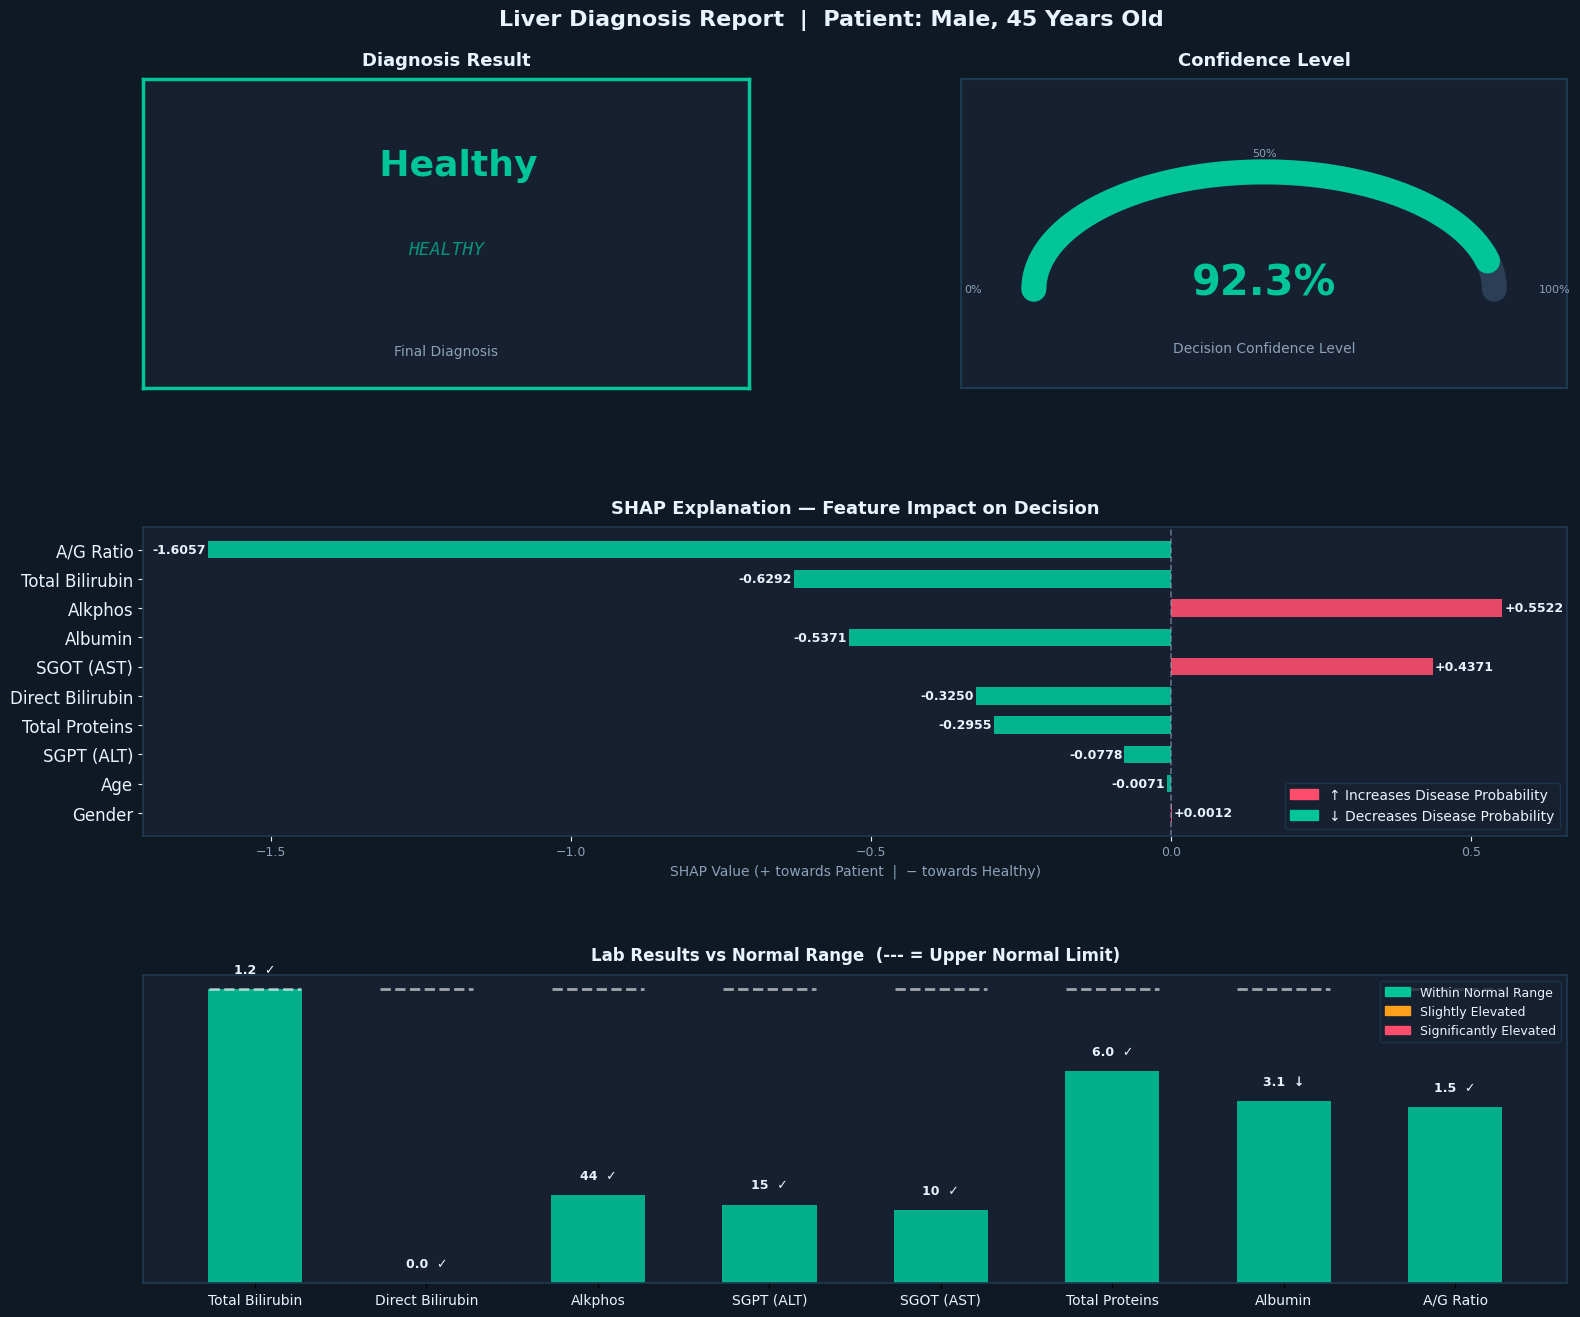

════════════════════════════════════════════════════
Diagnosis Result
════════════════════════════════════════════════════
  Status    : Healthy
  Confidence: 92.3%
════════════════════════════════════════════════════
Top 3 Factors Influencing the Decision:
    1. A/G Ratio                      Decreases Probability ↓  (SHAP=-1.6057)
    2. Total Bilirubin                Decreases Probability ↓  (SHAP=-0.6292)
    3. Alkphos                        Increases Probability ↑  (SHAP=+0.5522)
════════════════════════════════════════════════════
Please consult a doctor. This system is not a substitute for medical advice.
════════════════════════════════════════════════════


In [65]:
import joblib, numpy as np, pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.gridspec as gridspec
import shap, warnings
warnings.filterwarnings('ignore')

# ════════════════════════════════════════════════════════════
#  Input patient data Here
# ════════════════════════════════════════════════════════════
patient = {
    "Age of the patient"                    : 45,     
    "Gender of the patient"                 : 1,      
    "Total Bilirubin"                       : 1.2,     
    "Direct Bilirubin"                      : 0.0,  
    "Alkphos Alkaline Phosphotase"          : 44,     
    "Sgpt Alamine Aminotransferase"         : 15,      
    "Sgot Aspartate Aminotransferase"       : 10,      
    "Total Protiens"                        : 6.0,     
    "ALB Albumin"                           : 3.1,    
    "A/G Ratio Albumin and Globulin Ratio"  : 1.5,   
}
# ════════════════════════════════════════════════════════════

# ── Load saved pipeline ──────────────────────────────────────
model    = joblib.load('saved_pipelinev2/model.pkl')
scaler   = joblib.load('saved_pipelinev2/scaler.pkl')
features = joblib.load('saved_pipelinev2/features.pkl')

# ── Preprocess ───────────────────────────────────────────────
NORMAL_RANGES = {
    "Total Bilirubin"                      : (0.2,  1.2,  "mg/dL"),
    "Direct Bilirubin"                     : (0.0,  0.3,  "mg/dL"),
    "Alkphos Alkaline Phosphotase"         : (44,   147,  "IU/L"),
    "Sgpt Alamine Aminotransferase"        : (7,    56,   "IU/L"),
    "Sgot Aspartate Aminotransferase"      : (10,   40,   "IU/L"),
    "Total Protiens"                       : (6.0,  8.3,  "g/dL"),
    "ALB Albumin"                          : (3.5,  5.0,  "g/dL"),
    "A/G Ratio Albumin and Globulin Ratio" : (1.0,  2.5,  ""),
}

SKEWED_COLS = [
    "Total Bilirubin", "Direct Bilirubin",
    "Alkphos Alkaline Phosphotase",
    "Sgpt Alamine Aminotransferase",
    "Sgot Aspartate Aminotransferase",
]

# ── Name map (dict) ──────────────────────────────────────────
name_map = {
    "Age of the patient"                    : "Age",
    "Gender of the patient"                 : "Gender",
    "Total Bilirubin"                       : "Total Bilirubin",
    "Direct Bilirubin"                      : "Direct Bilirubin",
    "Alkphos Alkaline Phosphotase"          : "Alkphos",
    "Sgpt Alamine Aminotransferase"         : "SGPT (ALT)",
    "Sgot Aspartate Aminotransferase"       : "SGOT (AST)",
    "Total Protiens"                        : "Total Proteins",
    "ALB Albumin"                           : "Albumin",
    "A/G Ratio Albumin and Globulin Ratio"  : "A/G Ratio",
}

df_in = pd.DataFrame([patient])[features]
for col in SKEWED_COLS:
    if col in df_in.columns:
        df_in[col] = np.log1p(df_in[col].clip(lower=0))

X_scaled = scaler.transform(df_in)

# ── Predict ──────────────────────────────────────────────────
pred       = model.predict(X_scaled)[0]
prob_pos   = model.predict_proba(X_scaled)[0][1]
confidence = prob_pos if pred == 1 else (1 - prob_pos)

# ── SHAP values ──────────────────────────────────────────────
try:
    base_xgb  = dict(model.named_estimators_)['xgb']
    explainer = shap.TreeExplainer(base_xgb)
except:
    explainer = shap.TreeExplainer(model)

shap_vals_raw = explainer.shap_values(X_scaled)
if isinstance(shap_vals_raw, list):
    sv = shap_vals_raw[1][0]
else:
    sv = shap_vals_raw[0]

# ── Colors ───────────────────────────────────────────────────
COLORS = {
    'positive' : '#ff4d6d',
    'negative' : '#00c49a',
    'neutral'  : '#4cc9f0',
    'bg_panel' : '#162030',
    'text'     : '#e8f4fd',
    'subtext'  : '#8ca0b8',
    'border'   : '#1e3a52',
    'yellow'   : '#ffd60a',
    'orange'   : '#ff9f1c',
}

# ── Build Figure ─────────────────────────────────────────────
fig = plt.figure(figsize=(16, 14))
fig.patch.set_facecolor('#0f1923')

gs = gridspec.GridSpec(3, 2, figure=fig,
                       hspace=0.45, wspace=0.35,
                       top=0.92, bottom=0.06,
                       left=0.07, right=0.96)

# ────────────────────────────────────────────────────────────
# Panel 1 – Verdict Card (top-left)
# ────────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
ax1.set_facecolor(COLORS['bg_panel'])
for spine in ax1.spines.values():
    spine.set_edgecolor(COLORS['positive'] if pred == 1 else COLORS['negative'])
    spine.set_linewidth(2.5)
ax1.set_xticks([]); ax1.set_yticks([])

verdict_color = COLORS['positive'] if pred == 1 else COLORS['negative']
verdict_icon  = '' if pred == 1 else ''
verdict_text  = 'Liver Patient' if pred == 1 else 'Healthy'
verdict_en    = 'LIVER PATIENT' if pred == 1 else 'HEALTHY'

ax1.text(0.5, 0.72, verdict_icon + '  ' + verdict_text,
         transform=ax1.transAxes, ha='center', va='center',
         fontsize=26, fontweight='bold', color=verdict_color)
ax1.text(0.5, 0.45, verdict_en,
         transform=ax1.transAxes, ha='center', va='center',
         fontsize=13, color=verdict_color, alpha=0.7,
         fontfamily='monospace', fontstyle='italic')
ax1.text(0.5, 0.12, 'Final Diagnosis',
         transform=ax1.transAxes, ha='center', va='center',
         fontsize=10, color=COLORS['subtext'])
ax1.set_title('Diagnosis Result', color=COLORS['text'],
              fontsize=13, fontweight='bold', pad=10, loc='center')

# ────────────────────────────────────────────────────────────
# Panel 2 – Confidence Gauge (top-right)
# ────────────────────────────────────────────────────────────
ax2 = fig.add_subplot(gs[0, 1])
ax2.set_facecolor(COLORS['bg_panel'])
for spine in ax2.spines.values():
    spine.set_edgecolor(COLORS['border']); spine.set_linewidth(1.5)
ax2.set_xticks([]); ax2.set_yticks([])

theta_bg  = np.linspace(np.pi, 0, 200)
theta_val = np.linspace(np.pi, np.pi - confidence * np.pi, 200)
r = 0.38
cx, cy = 0.5, 0.32

ax2.plot(cx + r * np.cos(theta_bg), cy + r * np.sin(theta_bg),
         color='#2a3f55', linewidth=18, solid_capstyle='round',
         transform=ax2.transAxes, zorder=1)

gauge_color = (COLORS['negative'] if confidence >= 0.75
               else COLORS['orange'] if confidence >= 0.50
               else COLORS['positive'])

ax2.plot(cx + r * np.cos(theta_val), cy + r * np.sin(theta_val),
         color=gauge_color, linewidth=18, solid_capstyle='round',
         transform=ax2.transAxes, zorder=2)

ax2.text(0.5, 0.34, f'{confidence*100:.1f}%',
         transform=ax2.transAxes, ha='center', va='center',
         fontsize=30, fontweight='bold', color=gauge_color)
ax2.text(0.5, 0.13, 'Decision Confidence Level',
         transform=ax2.transAxes, ha='center', va='center',
         fontsize=10, color=COLORS['subtext'])

for angle, label in [(np.pi, '0%'), (np.pi/2, '50%'), (0, '100%')]:
    ax2.text(0.5 + (r+0.1)*np.cos(angle),
             0.32 + (r+0.06)*np.sin(angle),
             label, transform=ax2.transAxes,
             ha='center', va='center', fontsize=8,
             color=COLORS['subtext'])

ax2.set_xlim(0, 1); ax2.set_ylim(0, 1)
ax2.set_title('Confidence Level', color=COLORS['text'],
              fontsize=13, fontweight='bold', pad=10, loc='center')

# ────────────────────────────────────────────────────────────
# Panel 3 – SHAP Waterfall (middle, full-width)
# ────────────────────────────────────────────────────────────
ax3 = fig.add_subplot(gs[1, :])
ax3.set_facecolor(COLORS['bg_panel'])
for spine in ax3.spines.values():
    spine.set_edgecolor(COLORS['border']); spine.set_linewidth(1.2)

sorted_idx  = np.argsort(np.abs(sv))
feat_names  = [features[i] for i in sorted_idx]
shap_sorted = sv[sorted_idx]
labels      = [name_map.get(f, f) for f in feat_names]

bar_colors = [COLORS['positive'] if v > 0 else COLORS['negative']
              for v in shap_sorted]
bars = ax3.barh(labels, shap_sorted, color=bar_colors,
                height=0.6, edgecolor='none', alpha=0.9)

ax3.axvline(0, color=COLORS['subtext'], linewidth=1.2, linestyle='--', alpha=0.6)
ax3.set_facecolor(COLORS['bg_panel'])
ax3.tick_params(colors=COLORS['text'], labelsize=11)
ax3.xaxis.label.set_color(COLORS['subtext'])
for spine in ax3.spines.values():
    spine.set_edgecolor(COLORS['border'])
ax3.tick_params(axis='y', labelsize=12)
plt.setp(ax3.get_yticklabels(), color=COLORS['text'])
plt.setp(ax3.get_xticklabels(), color=COLORS['subtext'], fontsize=9)

for bar, val in zip(bars, shap_sorted):
    pad = 0.003
    ha  = 'left' if val >= 0 else 'right'
    x   = val + pad if val >= 0 else val - pad
    ax3.text(x, bar.get_y() + bar.get_height()/2,
             f'{val:+.4f}', va='center', ha=ha,
             color=COLORS['text'], fontsize=9, fontweight='bold')

legend_patches = [
    mpatches.Patch(color=COLORS['positive'], label='↑ Increases Disease Probability'),
    mpatches.Patch(color=COLORS['negative'], label='↓ Decreases Disease Probability'),
]
ax3.legend(handles=legend_patches, loc='lower right',
           facecolor=COLORS['bg_panel'], edgecolor=COLORS['border'],
           labelcolor=COLORS['text'], fontsize=10)
ax3.set_title('SHAP Explanation — Feature Impact on Decision',
              color=COLORS['text'], fontsize=13, fontweight='bold',
              pad=10, loc='center')
ax3.set_xlabel('SHAP Value (+ towards Patient  |  − towards Healthy)',
               color=COLORS['subtext'], fontsize=10)

# ────────────────────────────────────────────────────────────
# Panel 4 – Lab Values vs Normal Ranges (bottom, full-width)
# ────────────────────────────────────────────────────────────
ax4 = fig.add_subplot(gs[2, :])
ax4.set_facecolor(COLORS['bg_panel'])
for spine in ax4.spines.values():
    spine.set_edgecolor(COLORS['border']); spine.set_linewidth(1.2)

lab_keys   = list(NORMAL_RANGES.keys())
lab_labels = [name_map.get(k, k) for k in lab_keys]
vals_raw   = [patient[k] for k in lab_keys]
norms      = [NORMAL_RANGES[k] for k in lab_keys]

norm_vals, bar_cols, pct_labels = [], [], []
for v, (lo, hi, unit) in zip(vals_raw, norms):
    ceiling = hi * 2.2
    pct     = min(v / ceiling, 1.0)
    norm_vals.append(pct)
    ratio = v / hi
    bar_cols.append(
        COLORS['negative'] if ratio <= 1.0
        else COLORS['orange'] if ratio <= 1.5
        else COLORS['positive']
    )
    flag = '✓' if lo <= v <= hi else '↑' if v > hi else '↓'
    pct_labels.append(f'{v}  {flag}')

x     = np.arange(len(lab_keys))
bars4 = ax4.bar(x, norm_vals, color=bar_cols, width=0.55,
                edgecolor='none', alpha=0.88)

for i, (lo, hi, unit) in enumerate(norms):
    ceiling = hi * 2.2
    ax4.plot([i-0.27, i+0.27], [hi/ceiling, hi/ceiling],
             color='white', linewidth=2, linestyle='--', alpha=0.6)

for bar, label in zip(bars4, pct_labels):
    ax4.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             label, ha='center', va='bottom',
             color=COLORS['text'], fontsize=9, fontweight='bold')

ax4.set_xticks(x)
ax4.set_xticklabels(lab_labels, color=COLORS['text'], fontsize=10)
ax4.set_yticks([])
ax4.set_facecolor(COLORS['bg_panel'])
for spine in ax4.spines.values():
    spine.set_edgecolor(COLORS['border'])

legend4 = [
    mpatches.Patch(color=COLORS['negative'], label='Within Normal Range'),
    mpatches.Patch(color=COLORS['orange'],   label='Slightly Elevated'),
    mpatches.Patch(color=COLORS['positive'], label='Significantly Elevated'),
]
ax4.legend(handles=legend4, loc='upper right',
           facecolor=COLORS['bg_panel'], edgecolor=COLORS['border'],
           labelcolor=COLORS['text'], fontsize=9)
ax4.set_title('Lab Results vs Normal Range  (--- = Upper Normal Limit)',
              color=COLORS['text'], fontsize=12,
              fontweight='bold', pad=10, loc='center')

# ── Main title ───────────────────────────────────────────────
gender_label = 'Male' if patient['Gender of the patient'] == 1 else 'Female'
fig.suptitle(
    f'Liver Diagnosis Report  |  Patient: {gender_label}, {patient["Age of the patient"]} Years Old',
    fontsize=16, fontweight='bold', color=COLORS['text'], y=0.97)

plt.savefig('patient_report.png', dpi=150, bbox_inches='tight',
            facecolor=fig.get_facecolor())
plt.show()

# ── Console summary ──────────────────────────────────────────
sep = "═" * 52
print(sep)
print("Diagnosis Result")
print(sep)
print(f"  Status    : {'Liver Patient' if pred==1 else 'Healthy'}")
print(f"  Confidence: {confidence*100:.1f}%")
print(sep)

top3_idx = np.argsort(np.abs(sv))[::-1][:3]
print("Top 3 Factors Influencing the Decision:")
for rank, i in enumerate(top3_idx, 1):
    direction = "Increases Probability ↑" if sv[i] > 0 else "Decreases Probability ↓"
    print(f"    {rank}. {name_map.get(features[i], features[i]):<30} {direction}  (SHAP={sv[i]:+.4f})")
print(sep)
print("Please consult a doctor. This system is not a substitute for medical advice.")
print(sep)

In [ ]:
# Patient real data
# patient = {
#     "Age of the patient"                    : 45,      # العمر بالسنين
#     "Gender of the patient"                 : 1,       # 1 = Male | 0 = Female
#     "Total Bilirubin"                       : 2.8,     # mg/dL   (طبيعي: 0.2 – 1.2)
#     "Direct Bilirubin"                      : 1.2,     # mg/dL   (طبيعي: 0.0 – 0.3)
#     "Alkphos Alkaline Phosphotase"          : 44,     # IU/L    (طبيعي: 44 – 147)
#     "Sgpt Alamine Aminotransferase"         : 100,      # IU/L    (طبيعي: 7  – 56)
#     "Sgot Aspartate Aminotransferase"       : 88,      # IU/L    (طبيعي: 10 – 40)
#     "Total Protiens"                        : 6.5,     # g/dL    (طبيعي: 6.0 – 8.3)
#     "ALB Albumin"                           : 3.1,     # g/dL    (طبيعي: 3.5 – 5.0)
#     "A/G Ratio Albumin and Globulin Ratio"  : 0.9,     # ratio   (طبيعي: 1.0 – 2.5)
# }

In [ ]:
# Health real data
# patient = {
#     "Age of the patient"                    : 45,     
#     "Gender of the patient"                 : 1,      
#     "Total Bilirubin"                       : 1.2,     
#     "Direct Bilirubin"                      : 0.0,  
#     "Alkphos Alkaline Phosphotase"          : 44,     
#     "Sgpt Alamine Aminotransferase"         : 15,      
#     "Sgot Aspartate Aminotransferase"       : 10,      
#     "Total Protiens"                        : 6.0,     
#     "ALB Albumin"                           : 3.1,    
#     "A/G Ratio Albumin and Globulin Ratio"  : 1.5,   
# }

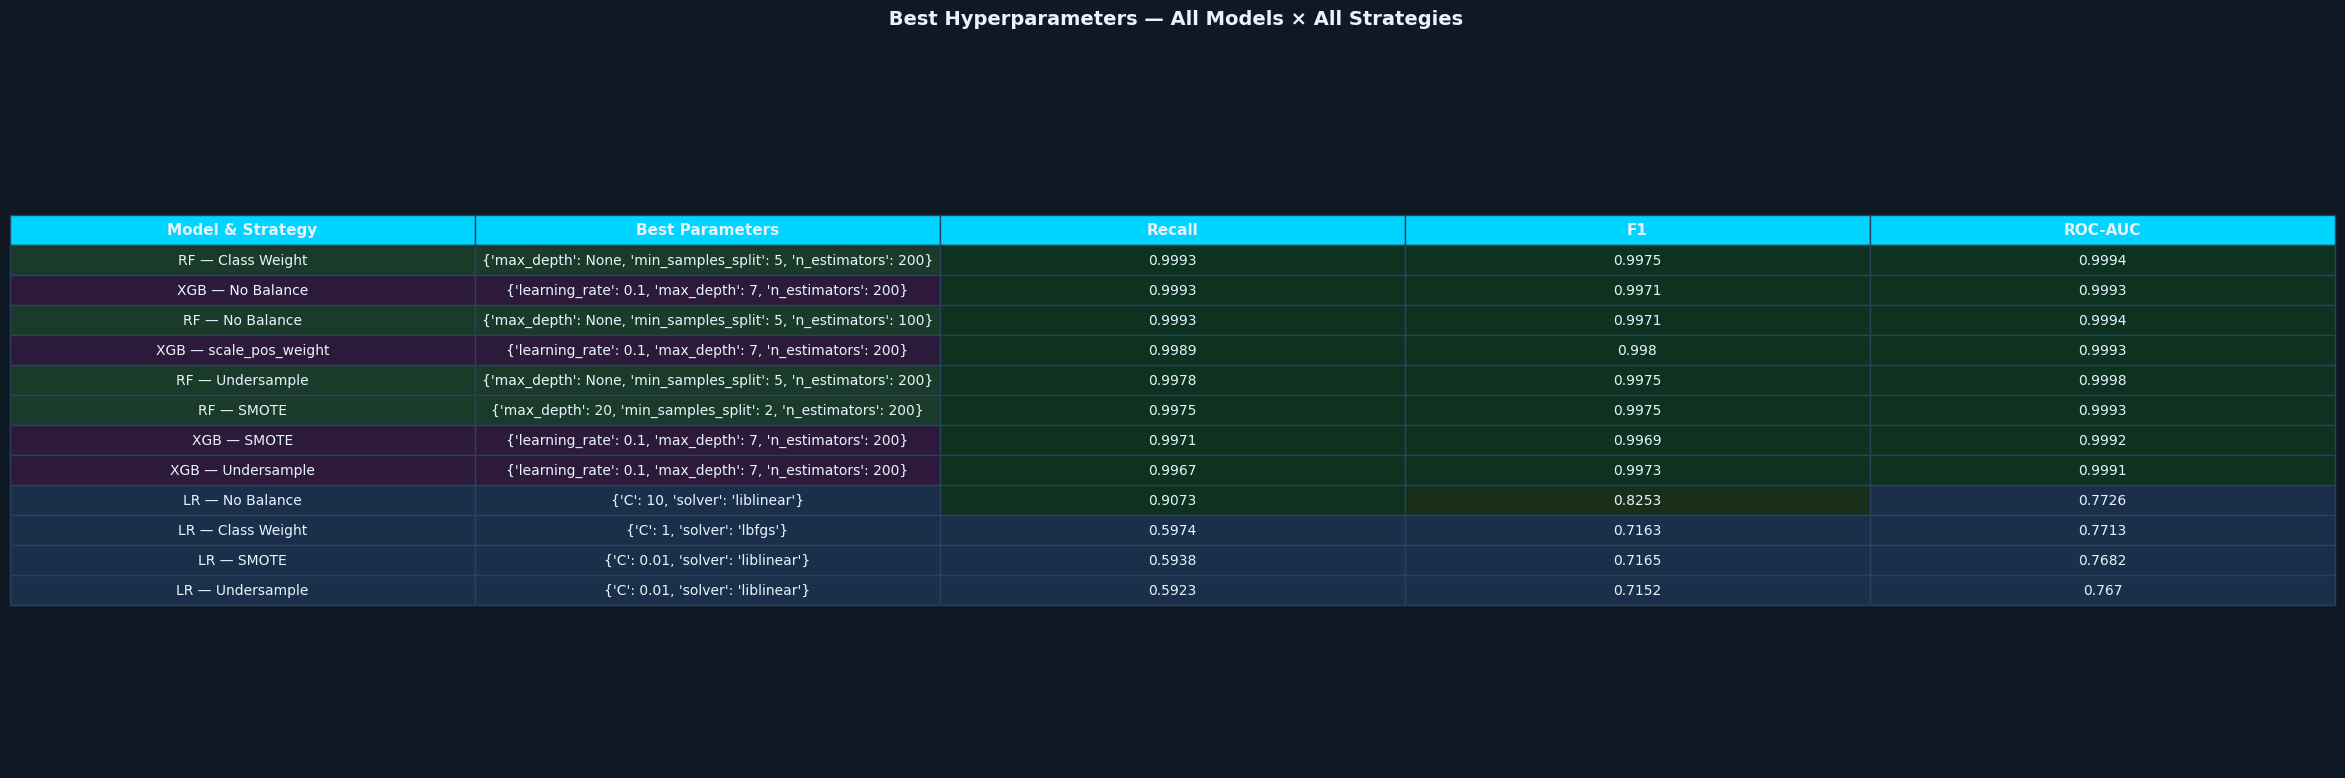

 Best Parameters table displayed & saved.


In [67]:

#   Best Hyperparameters — All Models & Strategies
params_data = []
for res in all_results:
    params_data.append({
        'Model & Strategy' : res['Label'],
        'Best Parameters'  : res.get('Best Params', 'N/A'),
        'Recall'           : round(res['Recall'], 4),
        'F1'               : round(res['F1'], 4),
        'ROC-AUC'          : round(res['ROC-AUC'], 4),
    })

params_df = pd.DataFrame(params_data).sort_values('Recall', ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(30, len(params_df) * 0.65 + 1.5))
fig.patch.set_facecolor('#0f1923')
ax.set_facecolor('#0f1923')
ax.axis('off')

col_labels = ['Model & Strategy', 'Best Parameters', 'Recall', 'F1', 'ROC-AUC']
cell_text  = params_df[col_labels].values.tolist()

row_colors = []
for label in params_df['Model & Strategy']:
    if 'LR' in label:
        row_colors.append(['#1a2f4a'] * len(col_labels))
    elif 'RF' in label:
        row_colors.append(['#1a3a2a'] * len(col_labels))
    else:
        row_colors.append(['#2d1a3a'] * len(col_labels))

tbl = ax.table(
    cellText=cell_text,
    colLabels=col_labels,
    cellLoc='center',
    loc='center',
    cellColours=row_colors,
)

tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1, 1.8)

for j in range(len(col_labels)):
    tbl[0, j].set_facecolor('#00d4ff')
    tbl[0, j].set_text_props(color='#0f1923', fontweight='bold', fontsize=11)

for (row, col), cell in tbl.get_celld().items():
    cell.set_edgecolor('#2a4060')
    cell.set_text_props(color='#e8f4fd')
    if col in [2, 3, 4] and row > 0:
        try:
            val = float(cell.get_text().get_text())
            if val >= 0.90:
                cell.set_facecolor('#0d3320')
            elif val >= 0.80:
                cell.set_facecolor('#1a2f1a')
        except:
            pass

ax.set_title(' Best Hyperparameters — All Models × All Strategies',
             color='#e8f4fd', fontsize=14, fontweight='bold', pad=20, loc='center')
plt.savefig('presentation_plots/best_params_table.png', dpi=150,
            bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print(" Best Parameters table displayed & saved.")


In [ ]:
# Radar chart for top 3
# from matplotlib.patches import FancyBboxPatch
# categories = ['Accuracy', 'Precision', 'Recall', 'F1', 'ROC-AUC']
# top3_data = results_df.head(3)

# angles = np.linspace(0, 2 * np.pi, len(categories), endpoint=False).tolist()
# angles += angles[:1]

# radar_ax = fig.add_subplot(122, polar=True)
# colors_radar = ['#E74C3C', '#3498DB', '#2ECC71']

# for idx, (_, row) in enumerate(top3_data.iterrows()):
#     values = [row[c] for c in categories]
#     values += values[:1]
#     radar_ax.plot(angles, values, 'o-', linewidth=2,
#                   color=colors_radar[idx], label=row['Label'])
#     radar_ax.fill(angles, values, alpha=0.1, color=colors_radar[idx])

# radar_ax.set_xticks(angles[:-1])
# radar_ax.set_xticklabels(categories, fontsize=9)
# radar_ax.set_ylim([0.6, 1.0])
# radar_ax.set_title('Top 3 Models — Radar Chart', fontsize=13, fontweight='bold', pad=20)
# radar_ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.15), fontsize=8)

# plt.tight_layout()
# plt.show()

In [ ]:
# loaded_model    = joblib.load(f'{save_dir}/model.pkl')
# loaded_scaler   = joblib.load(f'{save_dir}/scaler.pkl')
# loaded_features = joblib.load(f'{save_dir}/features.pkl')

# # Test on a sample
# sample_raw = X_test.iloc[14:17].copy()
# sample_scaled = loaded_scaler.transform(sample_raw)
# sample_preds = loaded_model.predict(sample_scaled)
# sample_probs = loaded_model.predict_proba(sample_scaled)[:, 1]

# print(" Pipeline loaded and verified!")
# print()
# print("Sample Predictions on 3 patients:")
# for i, (pred, prob) in enumerate(zip(sample_preds, sample_probs)):
#     status = '🔴 Liver Patient' if pred == 1 else '🟢 Healthy'
#     print(f"   Patient {i+1}: {status}  (confidence: {prob:.1%})")
